# Equidade e estabilidade temporal dos modelos calibrados

Como o desempenho se distribui entre subgrupos no teste de 2024 e quanto ele se mantém em 2025, sobre os cinco modelos selecionados da configuração final com calibração Platt, no limiar de sensibilidade-alvo de 0,80 fixado na validação cruzada do treino.
O critério de inclusão de subgrupos é a largura observada do intervalo de confiança da estatística C, e não um limiar arbitrário de eventos.
Lê os calibradores de `output/modelos_v2_calibrados/`, as bases das configurações em `data/processed/`, e a seleção de versões e os limiares de `analysis/results_calibracao/`.
Nenhum modelo é treinado, calibrado ou tem limiar reajustado.

## Etapas
1. Selecionar, em cada par base/otimizada, a versão de maior AUPRC na validação cruzada do treino.
2. Montar as partições de 2024 e de 2025 com as variáveis de estratificação no estado bruto.
3. Carregar os modelos selecionados, aplicar o calibrador Platt e conferir as probabilidades de 2024 contra as já gravadas.
4. Ler o limiar de cada modelo, fixado no treino e aplicado sem reajuste a 2024 e a 2025.
5. Descrever todos os subgrupos do teste de 2024, sem excluir nenhum, e contar a não resposta por variável.
6. Rodar o bootstrap em todos os subgrupos antes de qualquer filtro, com as mesmas reamostragens em todos os modelos.
7. Aplicar o critério de largura do intervalo de confiança e registrar quais subgrupos entram.
8. Confrontar os limiares de referência de 30 e de 100 óbitos com a largura que de fato entregariam.
9. Quantificar a disparidade por variável e modelo entre os subgrupos elegíveis.
10. Confrontar o padrão publicado, de pior desempenho em menores de 15 anos e no Nordeste, com o observado.
11. Avaliar os cinco modelos em 2024 e em 2025 com o mesmo limiar, e comparar a calibração por decil.

## Entradas
- `output/modelos_v2_calibrados/` (calibradores Platt)
- `output/metricas_v2_calibradas/` (predições já gravadas, para conferência)
- `data/processed/dengue_treated_corrigida.parquet`
- `data/processed/dengue_treated_notificacao.parquet`
- `analysis/results_calibracao/selecao_base_vs_otimizada.csv`
- `analysis/results_calibracao/limiares_teste_2024.csv`

## Saídas
- `analysis/results_equidade/selecao_versao_por_algoritmo.csv`
- `analysis/results_equidade/prevalencia_por_ano.csv`
- `analysis/results_equidade/verificacao_predicoes.csv`
- `analysis/results_equidade/limiares_aplicados.csv`
- `analysis/results_equidade/composicao_subgrupos_2024.csv`
- `analysis/results_equidade/nao_informado_por_variavel_2024.csv`
- `analysis/results_equidade/discriminacao_todos_subgrupos_2024.csv`
- `analysis/results_equidade/metricas_indefinidas_2024.csv`
- `analysis/results_equidade/largura_ic_por_eventos.csv`
- `analysis/results_equidade/criterio_subgrupos_2024.csv`
- `analysis/results_equidade/largura_referencia_30_100.csv`
- `analysis/results_equidade/largura_por_faixa_de_eventos.csv`
- `analysis/results_equidade/equidade_corrigida_2024.csv`
- `analysis/results_equidade/equidade_notificacao_2024.csv`
- `analysis/results_equidade/disparidade_por_variavel.csv`
- `analysis/results_equidade/comparacao_padrao_publicado.csv`
- `analysis/results_equidade/estabilidade_2024_2025.csv`
- `analysis/results_equidade/curva_calibracao_por_decil.csv`
- `analysis/results_equidade/desvio_calibracao_por_ano.csv`
- `analysis/plots/equidade/largura_ic_por_eventos.png`
- `analysis/plots/equidade/equidade_auprc_corrigida.png`
- `analysis/plots/equidade/equidade_roc_auc_corrigida.png`
- `analysis/plots/equidade/equidade_sensibilidade_corrigida.png`
- `analysis/plots/equidade/estabilidade_diferencas.png`
- `analysis/plots/equidade/calibracao_decis_2024_2025.png`

Importações, caminhos, constantes e formatadores em português.

In [1]:
import os
import sys
import time
import textwrap
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import configuracoes

PROC_DIR       = os.path.join(ROOT, 'data', 'processed')
DIR_CALIBRADOS = os.path.join(ROOT, 'output', 'modelos_v2_calibrados')
DIR_CALIBRADAS = os.path.join(ROOT, 'output', 'metricas_v2_calibradas')
DIR_RES_CAL    = os.path.join(ROOT, 'analysis', 'results_calibracao')
DIR_TABELAS    = os.path.join(ROOT, 'analysis', 'results_equidade')
DIR_FIGURAS    = os.path.join(ROOT, 'analysis', 'plots', 'equidade')
for _d in (DIR_TABELAS, DIR_FIGURAS):
    os.makedirs(_d, exist_ok=True)

RANDOM_STATE  = 42
N_BOOTSTRAP   = 2000
SENS_ALVO     = 0.80
CALIBRACAO    = 'Platt'
REGRA_LIMIAR  = 'sensibilidade 0,80 no treino'
N_DECIS       = 10
ANO_TESTE     = 2024
ANO_EXTERNO   = 2025

# Precisão no espírito de Riley et al. (2021): o subgrupo entra pela largura que o
# intervalo de confiança de fato alcança, e não por um número de eventos. A meta
# convencional para a estatística C é largura 0,1, exigida aqui nos cinco modelos.
LARGURA_ALVO       = 0.10
LIMIAR_ANTIGO      = 30
EVENTOS_REFERENCIA = (LIMIAR_ANTIGO, 100)

CONFIG_PRINCIPAL = 'corrigida'
CONFIG_COMPARACAO = 'notificacao'
CONFIGS = [CONFIG_PRINCIPAL, CONFIG_COMPARACAO]
# Chave interna -> rotulo publicado. As chaves nomeiam arquivos e nao mudam.
ROTULO_CONFIG = {'antiga': 'original', 'corrigida': 'final',
                 'notificacao': 'sem critérios de gravidade'}
# Ordem de exibicao pela chave, e nao pelo texto do rotulo.
ORDEM_CONFIG = {ROTULO_CONFIG[c]: i for i, c in enumerate(CONFIGS)}
SUFIXO_VERSAO = {'base': '', 'otimizada': '_tuned'}

ALGORITMOS = {
    'logistic_regression': 'Regressão Logística',
    'decision_tree':       'Árvore de Decisão',
    'random_forest':       'Random Forest',
    'xgboost':             'XGBoost',
    'lightgbm':            'LightGBM',
}
ORDEM_ALGO = {r: i for i, r in enumerate(ALGORITMOS.values())}

METRICAS = ['auprc', 'roc_auc', 'brier', 'bss',
            'sensibilidade', 'especificidade', 'vpp', 'vpn']
ROTULO_METRICA = {'auprc': 'AUPRC', 'roc_auc': 'ROC-AUC', 'brier': 'Brier Score',
                  'bss': 'Brier Skill Score', 'sensibilidade': 'Sensibilidade',
                  'especificidade': 'Especificidade', 'vpp': 'VPP', 'vpn': 'VPN'}
METRICAS_DISCRIMINACAO = ['roc_auc', 'auprc']
METRICAS_EQUIDADE = ['auprc', 'roc_auc', 'sensibilidade', 'especificidade', 'vpp', 'vpn']
METRICAS_ESTABILIDADE = ['sensibilidade', 'auprc', 'roc_auc', 'vpp', 'brier', 'bss']

# Paleta fixa por algoritmo, a mesma dos notebooks 09 a 11: a cor identifica o modelo e
# não muda quando o conjunto de modelos do painel muda.
CORES_ALGO = {'logistic_regression': '#2a78d6', 'decision_tree': '#eb6834',
              'random_forest': '#1baf7a', 'xgboost': '#eda100', 'lightgbm': '#e87ba4'}
CORES_ANO = {2024: '#2a78d6', 2025: '#eb6834'}
ROTULO_ALGO_CURTO = {
    'logistic_regression': 'Regressão\nLogística', 'decision_tree': 'Árvore de\nDecisão',
    'random_forest': 'Random\nForest', 'xgboost': 'XGBoost', 'lightgbm': 'LightGBM',
}
# Rótulos de eixo: os nomes completos ficam nas tabelas, aqui entram encurtados para
# não colidirem nos painéis estreitos.
ROTULO_SUBGRUPO_CURTO = {
    'menos de 15 anos': 'menos de\n15 anos', '15 a 59 anos': '15 a 59\nanos',
    '60 anos ou mais': '60 anos\nou mais',
    'Sem escolaridade ou fundamental I': 'Sem escol.\nou fund. I',
    'Fundamental II': 'Fund. II', 'Superior': 'Superior',
    'Não se aplica': 'Não se\naplica',
    'Centro-Oeste': 'Centro-\nOeste',
    'Não informado': 'Não\ninformado',
}
MARCAS_ANO = {2024: 'o', 2025: 's'}
COR_REF = '#a3a29c'
COR_TINTA = '#52514e'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'text.color': '#0b0b0b',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'legend.frameon': False,
})


def n_(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{int(x):,}'.replace(',', '.')


def v_(x, casas=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{x:.{casas}f}'.replace('.', ',')


def ic_(lo, hi, casas=3):
    return f'[{v_(lo, casas)}; {v_(hi, casas)}]'


def pct_(x, casas=1):
    return f'{x:.{casas}f}'.replace('.', ',') + '%'


def par_(texto, largura=96):
    return textwrap.fill(' '.join(texto.split()), largura)


def eixo_virgula(casas=2):
    return mpl.ticker.FuncFormatter(lambda x, pos=None: f'{x:.{casas}f}'.replace('.', ','))


def ajustar_eixo(ax, eixo='y', casas_min=2):
    obj, lim = (ax.xaxis, ax.get_xlim()) if eixo == 'x' else (ax.yaxis, ax.get_ylim())
    marcas = [t for t in (ax.get_xticks() if eixo == 'x' else ax.get_yticks())
              if lim[0] <= t <= lim[1]]
    casas = casas_min
    while casas < 5 and len({f'{t:.{casas}f}' for t in marcas}) < len(marcas):
        casas += 1
    obj.set_major_formatter(eixo_virgula(casas))


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(DIR_TABELAS, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


def salvar_fig(fig, nome):
    caminho = os.path.join(DIR_FIGURAS, nome)
    fig.savefig(caminho, dpi=300, bbox_inches='tight', facecolor='#ffffff')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


CRITERIO_TEXTO = (f'largura do IC 95% de ROC-AUC abaixo de {v_(LARGURA_ALVO, 2)} nos '
                  f'cinco modelos')

print(f'Configuração principal: {ROTULO_CONFIG[CONFIG_PRINCIPAL]} · '
      f'comparação: {ROTULO_CONFIG[CONFIG_COMPARACAO]}')
print(f'Calibração: {CALIBRACAO} · limiar: {REGRA_LIMIAR} · '
      f'{n_(N_BOOTSTRAP)} reamostragens · semente {RANDOM_STATE}')
print(f'Critério de inclusão de subgrupos: {CRITERIO_TEXTO}')

Configuração principal: final · comparação: sem critérios de gravidade
Calibração: Platt · limiar: sensibilidade 0,80 no treino · 2.000 reamostragens · semente 42
Critério de inclusão de subgrupos: largura do IC 95% de ROC-AUC abaixo de 0,10 nos cinco modelos


Seleciona, em cada par base/otimizada, a versão com maior AUPRC na validação cruzada do treino.

In [2]:
df_sel_bruta = pd.read_csv(os.path.join(DIR_RES_CAL, 'selecao_base_vs_otimizada.csv'))
df_sel_bruta = df_sel_bruta[(df_sel_bruta['calibracao'] == CALIBRACAO)
                            & (df_sel_bruta['regra_limiar'] == REGRA_LIMIAR)]

linhas = []
for cfg in CONFIGS:
    for algo, rotulo in ALGORITMOS.items():
        r = df_sel_bruta[(df_sel_bruta['algoritmo'] == rotulo)
                         & (df_sel_bruta['configuracao'] == ROTULO_CONFIG[cfg])].iloc[0]
        base, otim = float(r['auprc_vc_treino_base']), float(r['auprc_vc_treino_otimizada'])
        # Empate exato vai para a base, por parcimônia: menos hiperparâmetros ajustados.
        versao = 'otimizada' if otim > base else 'base'
        linhas.append({
            'algoritmo': rotulo, 'configuracao': ROTULO_CONFIG[cfg],
            'auprc_vc_treino_base': round(base, 4),
            'auprc_vc_treino_otimizada': round(otim, 4),
            'diferenca_auprc_vc_treino': round(otim - base, 4),
            'versao_selecionada': versao,
            'auprc_vc_treino_selecionada': round(max(base, otim), 4),
            'criterio': 'maior AUPRC na validação cruzada do treino'
                        if otim != base else 'empate exato, base por parcimônia',
            'n_base_treino': int(r['n_base_treino']), 'eventos_treino': int(r['eventos_treino']),
        })

df_selecao = pd.DataFrame(linhas)
df_selecao['_a'] = df_selecao['algoritmo'].map(ORDEM_ALGO)
df_selecao['_c'] = df_selecao['configuracao'].map(ORDEM_CONFIG)
df_selecao = (df_selecao.sort_values(['_c', '_a'])
              .drop(columns=['_c', '_a']).reset_index(drop=True))
salvar_tab(df_selecao, 'selecao_versao_por_algoritmo.csv')

VERSAO_SELECIONADA = {(r['configuracao'], r['algoritmo']): r['versao_selecionada']
                      for _, r in df_selecao.iterrows()}
display(df_selecao.drop(columns=['n_base_treino', 'eventos_treino']))
print(f'\nVersões otimizadas selecionadas: '
      f'{int((df_selecao["versao_selecionada"] == "otimizada").sum())} de {len(df_selecao)}')

[tabela] analysis/results_equidade/selecao_versao_por_algoritmo.csv  (10 linhas)


,algoritmo,configuracao,auprc_vc_treino_base,auprc_vc_treino_otimizada,diferenca_auprc_vc_treino,versao_selecionada,auprc_vc_treino_selecionada,criterio
0,Regressão Logística,final,0.6346,0.6347,0.0001,otimizada,0.6347,maior AUPRC na validação cruzada do treino
1,Árvore de Decisão,final,0.5730,0.6207,0.0477,otimizada,0.6207,maior AUPRC na validação cruzada do treino
2,Random Forest,final,0.6527,0.6530,0.0003,otimizada,0.6530,maior AUPRC na validação cruzada do treino
3,XGBoost,final,0.6298,0.6556,0.0258,otimizada,0.6556,maior AUPRC na validação cruzada do treino
4,LightGBM,final,0.6304,0.6477,0.0173,otimizada,0.6477,maior AUPRC na validação cruzada do treino
5,Regressão Logística,sem critérios de gravidade,0.2772,0.2819,0.0047,otimizada,0.2819,maior AUPRC na validação cruzada do treino
6,Árvore de Decisão,sem critérios de gravidade,0.2066,0.2144,0.0078,otimizada,0.2144,maior AUPRC na validação cruzada do treino
7,Random Forest,sem critérios de gravidade,0.2755,0.2755,0.0000,base,0.2755,"empate exato, base por parcimônia"
8,XGBoost,sem critérios de gravidade,0.2556,0.2982,0.0426,otimizada,0.2982,maior AUPRC na validação cruzada do treino
9,LightGBM,sem critérios de gravidade,0.2583,0.2926,0.0343,otimizada,0.2926,maior AUPRC na validação cruzada do treino



Versões otimizadas selecionadas: 9 de 10


Monta as partições de 2024 e de 2025 das duas configurações, com as variáveis de estratificação no estado bruto.

In [3]:
MAPA_REGIAO = {'1': 'Norte', '2': 'Nordeste', '3': 'Sudeste', '4': 'Sul', '5': 'Centro-Oeste'}
MAPA_SEXO = {'F': 'Feminino', 'M': 'Masculino'}
MAPA_RACA = {1: 'Branca', 2: 'Preta', 3: 'Amarela', 4: 'Parda', 5: 'Indígena'}
MAPA_ESCOLARIDADE = {
    0: 'Sem escolaridade ou fundamental I', 1: 'Sem escolaridade ou fundamental I',
    2: 'Sem escolaridade ou fundamental I', 3: 'Fundamental II', 4: 'Fundamental II',
    5: 'Médio', 6: 'Médio', 7: 'Superior', 8: 'Superior',
    10: 'Não se aplica',
}
FAIXAS_IDADE = ([-np.inf, 15, 60, np.inf],
                ['menos de 15 anos', '15 a 59 anos', '60 anos ou mais'])

VARIAVEIS = {
    'Faixa etária':  'faixa_etaria',
    'Sexo':          'sexo',
    'Raça/cor':      'raca_cor',
    'Escolaridade':  'escolaridade',
    'Macrorregião':  'macrorregiao',
}
ORDEM_SUBGRUPO = {
    'Faixa etária': FAIXAS_IDADE[1],
    'Sexo': ['Feminino', 'Masculino'],
    'Raça/cor': ['Branca', 'Preta', 'Amarela', 'Parda', 'Indígena'],
    'Escolaridade': ['Sem escolaridade ou fundamental I', 'Fundamental II', 'Médio',
                     'Superior', 'Não se aplica'],
    'Macrorregião': ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste'],
}

# Na codificacao corrigida raca/cor e escolaridade declaram o proprio ausente ao
# codificador, com coluna na matriz de desenho: o modelo tem um comportamento proprio
# ali, e por isso a nao resposta delas entra como subgrupo e recebe n, obitos, ponto e
# intervalo. Nas demais o ausente e residual -- 10 registros na idade, 98 no sexo,
# nenhum na UF -- e segue apenas contado, sem virar subgrupo.
SUBGRUPO_NAO_INFORMADO = 'Não informado'
VARIAVEIS_COM_NAO_RESPOSTA = ('Raça/cor', 'Escolaridade')
for _rotulo_var in VARIAVEIS_COM_NAO_RESPOSTA:
    if SUBGRUPO_NAO_INFORMADO not in ORDEM_SUBGRUPO[_rotulo_var]:
        ORDEM_SUBGRUPO[_rotulo_var] = (ORDEM_SUBGRUPO[_rotulo_var]
                                       + [SUBGRUPO_NAO_INFORMADO])

# "Nao se aplica" nao e um nivel de escolaridade: e a categoria de nao aplicacao do
# campo, que na coorte se concentra nas primeiras idades. Dentro do calculo ela
# reexpressa, numa segunda variavel, a disparidade por faixa etaria que ja e reportada
# na propria faixa etaria. Recebe o mesmo tratamento do "nao informado" -- reportada
# com n, obitos, ponto e intervalo, e fora do calculo de disparidade -- mas com motivo
# proprio, porque a razao da exclusao e outra.
SUBGRUPO_NAO_SE_APLICA = 'Não se aplica'
NAO_RESPOSTA_ESTRUTURAL = {('Escolaridade', SUBGRUPO_NAO_SE_APLICA)}
MOTIVO_NAO_RESPOSTA = {SUBGRUPO_NAO_INFORMADO: 'não resposta',
                       SUBGRUPO_NAO_SE_APLICA: 'não resposta estrutural'}
PARES_NAO_RESPOSTA = ({(v, SUBGRUPO_NAO_INFORMADO) for v in VARIAVEIS_COM_NAO_RESPOSTA}
                      | NAO_RESPOSTA_ESTRUTURAL)
PAPEL_NIVEL = 'nível da variável'


def estratificar(df):
    '''Rótulos das cinco variáveis de estratificação. Códigos de ignorado já chegam
    como NaN de utils.treat_data, e é o NaN que marca o "não informado".

    Em raça/cor e escolaridade esse NaN vira uma categoria com nome; nas outras três ele
    fica como NaN e o registro não entra em nenhum subgrupo.
    '''
    e = pd.DataFrame(index=df.index)
    e['faixa_etaria'] = pd.cut(df['age_years'], bins=FAIXAS_IDADE[0],
                               labels=FAIXAS_IDADE[1], right=False).astype(object)
    e['sexo'] = df['CS_SEXO'].map(MAPA_SEXO)
    e['raca_cor'] = df['CS_RACA'].map(MAPA_RACA)
    e['escolaridade'] = df['CS_ESCOL_N'].map(MAPA_ESCOLARIDADE)
    e['macrorregiao'] = df['SG_UF'].astype(str).str[0].map(MAPA_REGIAO)
    for rotulo_var in VARIAVEIS_COM_NAO_RESPOSTA:
        col = VARIAVEIS[rotulo_var]
        e[col] = e[col].where(e[col].notna(), SUBGRUPO_NAO_INFORMADO)
    return e


particoes, linhas = {}, []
for cfg in CONFIGS:
    df = pd.read_parquet(os.path.join(PROC_DIR, f'dengue_treated_{cfg}.parquet'),
                         engine='pyarrow')
    preds = configuracoes.preditores(cfg)
    p = {}
    for ano in (ANO_TESTE, ANO_EXTERNO):
        m = (df['year'] == ano) & df['target'].notna()
        sub = df.loc[m].reset_index(drop=True)
        p[ano] = {
            'X': sub[preds],
            'y': sub['target'].astype(int).to_numpy(),
            'estratos': estratificar(sub),
        }
        linhas.append({
            'configuracao': ROTULO_CONFIG[cfg], 'ano': ano,
            'n_preditores': len(preds), 'n_base': len(sub),
            'eventos': int(sub['target'].sum()),
            'prevalencia_pct': round(float(sub['target'].mean()) * 100, 3),
        })
    particoes[cfg] = p

Y_2024 = particoes[CONFIG_PRINCIPAL][ANO_TESTE]['y']
Y_2025 = particoes[CONFIG_PRINCIPAL][ANO_EXTERNO]['y']
for cfg in CONFIGS:
    for ano, y_ref in ((ANO_TESTE, Y_2024), (ANO_EXTERNO, Y_2025)):
        assert np.array_equal(particoes[cfg][ano]['y'], y_ref), f'{cfg}/{ano} desalinhado'

ESTRATOS_2024 = particoes[CONFIG_PRINCIPAL][ANO_TESTE]['estratos']
N_2024, EVENTOS_2024 = len(Y_2024), int(Y_2024.sum())
N_2025, EVENTOS_2025 = len(Y_2025), int(Y_2025.sum())
PREV_2024, PREV_2025 = EVENTOS_2024 / N_2024, EVENTOS_2025 / N_2025

df_prevalencia = pd.DataFrame(linhas)
salvar_tab(df_prevalencia, 'prevalencia_por_ano.csv')
display(df_prevalencia)
print(f'\nPrevalência: {pct_(PREV_2024 * 100, 2)} em {ANO_TESTE} contra '
      f'{pct_(PREV_2025 * 100, 2)} em {ANO_EXTERNO}')

[tabela] analysis/results_equidade/prevalencia_por_ano.csv  (4 linhas)


,configuracao,ano,n_preditores,n_base,eventos,prevalencia_pct
0,final,2024,53,160302,5292,3.301
1,final,2025,53,63066,1530,2.426
2,sem critérios de gravidade,2024,37,160302,5292,3.301
3,sem critérios de gravidade,2025,37,63066,1530,2.426



Prevalência: 3,30% em 2024 contra 2,43% em 2025


Carrega os dez modelos selecionados, aplica o calibrador Platt e confere as probabilidades de 2024 contra as já gravadas em `output/`.

In [4]:
def caminho_calibrador(algo, cfg, versao):
    return os.path.join(DIR_CALIBRADOS,
                        f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}_calibradores.joblib')


def chave_de(algo, cfg):
    return f'{algo}|{cfg}'


probabilidades, linhas = {}, []
t0 = time.perf_counter()
for cfg in CONFIGS:
    for algo, rotulo in ALGORITMOS.items():
        versao = VERSAO_SELECIONADA[(ROTULO_CONFIG[cfg], rotulo)]
        d = joblib.load(caminho_calibrador(algo, cfg, versao))
        assert d['algoritmo'] == algo and d['configuracao'] == cfg and d['versao'] == versao
        platt = d['calibradores']['platt']
        k = chave_de(algo, cfg)
        probabilidades[k] = {}
        for ano in (ANO_TESTE, ANO_EXTERNO):
            bruta = d['pipeline'].predict_proba(particoes[cfg][ano]['X'])[:, 1]
            probabilidades[k][ano] = np.clip(platt.predict(bruta), 0.0, 1.0)
        gravada = pd.read_parquet(os.path.join(
            DIR_CALIBRADAS,
            f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}_predicoes_platt.parquet'))
        linhas.append({
            'algoritmo': rotulo, 'configuracao': ROTULO_CONFIG[cfg], 'versao': versao,
            'n_base_2024': N_2024, 'eventos_2024': EVENTOS_2024,
            'n_base_2025': N_2025, 'eventos_2025': EVENTOS_2025,
            'delta_max_2024_vs_gravado': float(np.abs(
                gravada['y_proba'].to_numpy() - probabilidades[k][ANO_TESTE]).max()),
            'risco_medio_2024': round(float(probabilidades[k][ANO_TESTE].mean()), 5),
            'risco_medio_2025': round(float(probabilidades[k][ANO_EXTERNO].mean()), 5),
        })

df_predicoes = pd.DataFrame(linhas)
df_predicoes['_a'] = df_predicoes['algoritmo'].map(ORDEM_ALGO)
df_predicoes['_c'] = df_predicoes['configuracao'].map(ORDEM_CONFIG)
df_predicoes = (df_predicoes.sort_values(['_c', '_a'])
                .drop(columns=['_c', '_a']).reset_index(drop=True))
salvar_tab(df_predicoes, 'verificacao_predicoes.csv')
display(df_predicoes[['algoritmo', 'configuracao', 'versao', 'delta_max_2024_vs_gravado',
                      'risco_medio_2024', 'risco_medio_2025']])
print(f'\nMaior diferença contra as probabilidades gravadas em output/: '
      f'{df_predicoes["delta_max_2024_vs_gravado"].max():.2e} - '
      f'{time.perf_counter() - t0:.1f}s')

[tabela] analysis/results_equidade/verificacao_predicoes.csv  (10 linhas)


,algoritmo,configuracao,versao,delta_max_2024_vs_gravado,risco_medio_2024,risco_medio_2025
0,Regressão Logística,final,otimizada,0.000000e+00,0.03377,0.03074
1,Árvore de Decisão,final,otimizada,0.000000e+00,0.03084,0.02748
2,Random Forest,final,otimizada,0.000000e+00,0.03085,0.02707
3,XGBoost,final,otimizada,0.000000e+00,0.03198,0.02766
4,LightGBM,final,otimizada,0.000000e+00,0.03234,0.02832
5,Regressão Logística,sem critérios de gravidade,otimizada,0.000000e+00,0.03406,0.03387
6,Árvore de Decisão,sem critérios de gravidade,otimizada,0.000000e+00,0.03082,0.03048
7,Random Forest,sem critérios de gravidade,base,9.992007e-16,0.03490,0.03258
8,XGBoost,sem critérios de gravidade,otimizada,0.000000e+00,0.03433,0.03304
9,LightGBM,sem critérios de gravidade,otimizada,0.000000e+00,0.03443,0.03317



Maior diferença contra as probabilidades gravadas em output/: 9.99e-16 - 27.1s


Lê o limiar de cada modelo selecionado, fixado na validação cruzada do treino e aplicado sem reajuste a 2024 e a 2025.

In [5]:
df_lim_bruta = pd.read_csv(os.path.join(DIR_RES_CAL, 'limiares_teste_2024.csv'))
df_lim_bruta = df_lim_bruta[(df_lim_bruta['calibracao'] == CALIBRACAO)
                            & (df_lim_bruta['regra_limiar'] == REGRA_LIMIAR)]

LIMIARES, linhas = {}, []
for cfg in CONFIGS:
    for algo, rotulo in ALGORITMOS.items():
        versao = VERSAO_SELECIONADA[(ROTULO_CONFIG[cfg], rotulo)]
        r = df_lim_bruta[(df_lim_bruta['algoritmo'] == rotulo)
                         & (df_lim_bruta['configuracao'] == ROTULO_CONFIG[cfg])
                         & (df_lim_bruta['versao'] == versao)].iloc[0]
        limiar = float(r['limiar'])
        LIMIARES[chave_de(algo, cfg)] = limiar
        obtida = float((probabilidades[chave_de(algo, cfg)][ANO_TESTE] >= limiar)[
            Y_2024 == 1].mean())
        linhas.append({
            'algoritmo': rotulo, 'configuracao': ROTULO_CONFIG[cfg], 'versao': versao,
            'calibracao': CALIBRACAO, 'regra_limiar': REGRA_LIMIAR,
            'limiar': round(limiar, 6),
            'sensibilidade_vc_treino': float(r['sensibilidade_vc_treino']),
            'sensibilidade_2024_registrada': float(r['sensibilidade']),
            'sensibilidade_2024_recalculada': round(obtida, 4),
            'n_base_treino': int(r['n_base_treino']), 'eventos_treino': int(r['eventos_treino']),
            'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
        })

df_limiares = pd.DataFrame(linhas)
df_limiares['_a'] = df_limiares['algoritmo'].map(ORDEM_ALGO)
df_limiares['_c'] = df_limiares['configuracao'].map(ORDEM_CONFIG)
df_limiares = (df_limiares.sort_values(['_c', '_a'])
               .drop(columns=['_c', '_a']).reset_index(drop=True))
assert (df_limiares['sensibilidade_2024_recalculada']
        - df_limiares['sensibilidade_2024_registrada']).abs().max() < 5e-4
salvar_tab(df_limiares, 'limiares_aplicados.csv')
display(df_limiares[['algoritmo', 'configuracao', 'versao', 'limiar',
                     'sensibilidade_vc_treino', 'sensibilidade_2024_recalculada']])

[tabela] analysis/results_equidade/limiares_aplicados.csv  (10 linhas)


,algoritmo,configuracao,versao,limiar,sensibilidade_vc_treino,sensibilidade_2024_recalculada
0,Regressão Logística,final,otimizada,0.038431,0.8003,0.7989
1,Árvore de Decisão,final,otimizada,0.019525,0.8075,0.8462
2,Random Forest,final,otimizada,0.017056,0.8003,0.7935
3,XGBoost,final,otimizada,0.038764,0.8003,0.7787
4,LightGBM,final,otimizada,0.021941,0.8003,0.7972
5,Regressão Logística,sem critérios de gravidade,otimizada,0.020587,0.8003,0.8279
6,Árvore de Decisão,sem critérios de gravidade,otimizada,0.011879,0.8003,0.8551
7,Random Forest,sem critérios de gravidade,base,0.014331,0.8003,0.8148
8,XGBoost,sem critérios de gravidade,otimizada,0.019924,0.8003,0.8178
9,LightGBM,sem critérios de gravidade,otimizada,0.018903,0.8003,0.8224


Define as métricas com pesos, que permitem usar as mesmas reamostragens em todos os modelos, e o gerador das distribuições de bootstrap.

In [6]:
def preparar(y, p, limiar):
    '''Pré-calcula por modelo tudo o que não depende da reamostragem.'''
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    ordem = np.argsort(-p, kind='stable').astype(np.int32)
    p_ord = p[ordem]
    positivo = p >= limiar
    evento = y == 1
    return {
        'ordem': ordem,
        'y_ord': y[ordem],
        'corte': np.r_[np.flatnonzero(np.diff(p_ord)), len(p_ord) - 1],
        'quad': (p - y) ** 2,
        'celas': np.column_stack([positivo & evento, positivo & ~evento,
                                  ~positivo & evento, ~positivo & ~evento]
                                 ).astype(np.float64),
    }


def _razao(numerador, denominador):
    '''Razão indefinida quando o denominador é zero, para a métrica virar NaN em vez
    de um número sem sentido.'''
    return float(numerador / denominador) if denominador > 0 else np.nan


def metricas_pesadas(pre, w):
    '''Métricas da reamostragem descrita pelos pesos w. Com w = 1 reproduz as
    definições usadas em notebooks/10_calibracao.'''
    w_ord = w[pre['ordem']]
    y_ord = pre['y_ord']
    vp_c = np.cumsum(w_ord * y_ord)[pre['corte']]
    fp_c = np.cumsum(w_ord * (1.0 - y_ord))[pre['corte']]
    n_pos, n_neg = float(vp_c[-1]), float(fp_c[-1])
    total = w.sum()

    # Sem evento ou sem não-evento na reamostragem não existe curva a integrar:
    # AUPRC e ROC-AUC ficam indefinidas e entram como NaN, contadas mais adiante.
    if n_pos > 0 and n_neg > 0:
        precisao = vp_c / np.maximum(vp_c + fp_c, 1e-12)
        revocacao = vp_c / n_pos
        auprc = float(np.sum(np.diff(np.r_[0.0, revocacao]) * precisao))
        roc = float(np.trapezoid(np.r_[0.0, revocacao], np.r_[0.0, fp_c / n_neg]))
    else:
        auprc = roc = np.nan

    brier = float(np.dot(w, pre['quad']) / total)
    prev = n_pos / total
    brier_ref = prev * (1.0 - prev)
    bss = float(1.0 - brier / brier_ref) if brier_ref > 0 else np.nan

    vp, fp, fn, vn = w @ pre['celas']
    return {
        'auprc': auprc, 'roc_auc': roc, 'brier': brier, 'bss': bss,
        'sensibilidade': _razao(vp, vp + fn),
        'especificidade': _razao(vn, vn + fp),
        'vpp': _razao(vp, vp + fp),
        'vpn': _razao(vn, vn + fn),
    }


def distribuicoes(y, probas, limiares, n_boot=N_BOOTSTRAP, semente=RANDOM_STATE):
    '''Roda o bootstrap uma vez e reaproveita cada reamostragem em todos os modelos:
    a réplica b é o mesmo sorteio de linhas para todos eles.'''
    n = len(y)
    pre = {k: preparar(y, probas[k], limiares[k]) for k in probas}
    ponto = {k: metricas_pesadas(pre[k], np.ones(n)) for k in probas}
    acum = {k: np.empty((n_boot, len(METRICAS))) for k in probas}
    gerador = np.random.default_rng(semente)
    for b in range(n_boot):
        w = np.bincount(gerador.integers(0, n, n), minlength=n).astype(np.float64)
        for k in probas:
            m = metricas_pesadas(pre[k], w)
            acum[k][b] = [m[nome] for nome in METRICAS]
    return ponto, {k: pd.DataFrame(v, columns=METRICAS) for k, v in acum.items()}


def ic95(serie):
    '''IC percentil sobre as réplicas em que a métrica ficou definida.'''
    v = np.asarray(serie, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan, np.nan
    return float(np.quantile(v, 0.025)), float(np.quantile(v, 0.975))


def n_validas(serie):
    return int(np.isfinite(np.asarray(serie, dtype=float)).sum())


print('Métricas com pesos, ponto e distribuições de bootstrap definidas.')
print('Métricas indefinidas entram como NaN e são contadas por subgrupo.')

Métricas com pesos, ponto e distribuições de bootstrap definidas.
Métricas indefinidas entram como NaN e são contadas por subgrupo.


Descreve todos os subgrupos no teste de 2024, sem excluir nenhum, e conta quantos registros ficam de fora por não informado em cada variável.

In [7]:
linhas, nao_informado = [], []
for rotulo_var, col in VARIAVEIS.items():
    coluna = ESTRATOS_2024[col]
    # Onde a nao resposta virou subgrupo ela tem nome e nao e mais NaN: a contagem
    # segue a mesma nas duas situacoes se for feita pelo criterio de cada uma.
    vira_subgrupo = rotulo_var in VARIAVEIS_COM_NAO_RESPOSTA
    m_ausente = ((coluna == SUBGRUPO_NAO_INFORMADO) if vira_subgrupo
                 else coluna.isna()).to_numpy()
    ausentes = int(m_ausente.sum())
    nao_informado.append({
        'variavel': rotulo_var, 'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
        'nao_informado': ausentes,
        'nao_informado_pct': round(ausentes / N_2024 * 100, 2),
        'eventos_nao_informado': int(Y_2024[m_ausente].sum()),
        'entra_como_subgrupo': 'sim' if vira_subgrupo else 'não',
    })
    for sg in ORDEM_SUBGRUPO[rotulo_var]:
        m = (coluna == sg).to_numpy()
        n, ev = int(m.sum()), int(Y_2024[m].sum())
        if n == 0:
            continue
        linhas.append({
            'variavel': rotulo_var, 'subgrupo': sg, 'n_base': n, 'eventos': ev,
            'categoria_de_nao_resposta': ('sim' if (rotulo_var, sg) in PARES_NAO_RESPOSTA
                                          else 'não'),
            'papel_na_variavel': MOTIVO_NAO_RESPOSTA.get(sg, PAPEL_NIVEL)
                                 if (rotulo_var, sg) in PARES_NAO_RESPOSTA else PAPEL_NIVEL,
            'prevalencia_pct': round(ev / n * 100, 2),
            'participacao_pct': round(n / N_2024 * 100, 2),
            'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
        })

df_composicao = pd.DataFrame(linhas)
df_nao_informado = pd.DataFrame(nao_informado)
salvar_tab(df_composicao, 'composicao_subgrupos_2024.csv')
salvar_tab(df_nao_informado, 'nao_informado_por_variavel_2024.csv')

TODOS_SUBGRUPOS = {rotulo_var: [r['subgrupo'] for _, r in df_composicao.iterrows()
                                if r['variavel'] == rotulo_var]
                   for rotulo_var in VARIAVEIS}
# A nao resposta e reportada com n, obitos, ponto e intervalo, mas nao e uma categoria
# da variavel: fica fora do criterio de largura e fora do calculo de disparidade, que
# comparam categorias entre si.
NAO_RESPOSTA = {(r['variavel'], r['subgrupo']) for _, r in df_composicao.iterrows()
                if r['categoria_de_nao_resposta'] == 'sim'}
SUBGRUPOS_VALIDOS = {rotulo_var: [s for s in TODOS_SUBGRUPOS[rotulo_var]
                                  if (rotulo_var, s) not in NAO_RESPOSTA]
                     for rotulo_var in VARIAVEIS}
display(df_composicao.drop(columns=['n_base_teste', 'eventos_teste']))
display(df_nao_informado)
n_estrutural = len(NAO_RESPOSTA & NAO_RESPOSTA_ESTRUTURAL)
print(f'\nSubgrupos levados ao bootstrap, nenhum excluído: '
      f'{sum(len(v) for v in TODOS_SUBGRUPOS.values())}: '
      f'{sum(len(v) for v in SUBGRUPOS_VALIDOS.values())} categorias das cinco variáveis, '
      f'{len(NAO_RESPOSTA) - n_estrutural} de não resposta e '
      f'{n_estrutural} de não resposta estrutural')
print(f'Menor subgrupo: {df_composicao.loc[df_composicao["eventos"].idxmin(), "variavel"]} = '
      f'{df_composicao.loc[df_composicao["eventos"].idxmin(), "subgrupo"]}, '
      f'{n_(df_composicao["eventos"].min())} óbitos')

[tabela] analysis/results_equidade/composicao_subgrupos_2024.csv  (22 linhas)
[tabela] analysis/results_equidade/nao_informado_por_variavel_2024.csv  (5 linhas)


,variavel,subgrupo,n_base,eventos,categoria_de_nao_resposta,papel_na_variavel,prevalencia_pct,participacao_pct
0,Faixa etária,menos de 15 anos,27707,160,não,nível da variável,0.58,17.28
1,Faixa etária,15 a 59 anos,85268,1648,não,nível da variável,1.93,53.19
2,Faixa etária,60 anos ou mais,47317,3484,não,nível da variável,7.36,29.52
3,Sexo,Feminino,87636,2665,não,nível da variável,3.04,54.67
4,Sexo,Masculino,72568,2625,não,nível da variável,3.62,45.27
5,Raça/cor,Branca,77295,2839,não,nível da variável,3.67,48.22
6,Raça/cor,Preta,5565,248,não,nível da variável,4.46,3.47
7,Raça/cor,Amarela,1729,52,não,nível da variável,3.01,1.08
8,Raça/cor,Parda,55570,1623,não,nível da variável,2.92,34.67
9,Raça/cor,Indígena,410,14,não,nível da variável,3.41,0.26


,variavel,n_base_teste,eventos_teste,nao_informado,nao_informado_pct,eventos_nao_informado,entra_como_subgrupo
0,Faixa etária,160302,5292,10,0.01,0,não
1,Sexo,160302,5292,98,0.06,2,não
2,Raça/cor,160302,5292,19733,12.31,516,sim
3,Escolaridade,160302,5292,80838,50.43,2828,sim
4,Macrorregião,160302,5292,0,0.00,0,não



Subgrupos levados ao bootstrap, nenhum excluído: 22: 19 categorias das cinco variáveis, 2 de não resposta e 1 de não resposta estrutural
Menor subgrupo: Raça/cor = Indígena, 14 óbitos


Roda o bootstrap em todos os subgrupos da configuração final, antes de qualquer filtro: ROC-AUC, AUPRC e as métricas operacionais no limiar, com as mesmas 2.000 reamostragens em todos os modelos.

In [8]:
def equidade(cfg):
    '''Uma linha por subgrupo e modelo, com IC 95% percentil. Nenhum subgrupo é
    excluído: o critério de inclusão sai depois, da largura dos intervalos.'''
    estratos = particoes[cfg][ANO_TESTE]['estratos']
    chaves = [chave_de(algo, cfg) for algo in ALGORITMOS]
    linhas = []
    for rotulo_var, col in VARIAVEIS.items():
        for sg in TODOS_SUBGRUPOS[rotulo_var]:
            m = (estratos[col] == sg).to_numpy()
            y_sg = Y_2024[m]
            n, ev = int(m.sum()), int(y_sg.sum())
            ponto, dist = distribuicoes(
                y_sg,
                {k: probabilidades[k][ANO_TESTE][m] for k in chaves},
                {k: LIMIARES[k] for k in chaves})
            for algo in ALGORITMOS:
                k = chave_de(algo, cfg)
                linha = {
                    'variavel': rotulo_var, 'subgrupo': sg,
                    'algoritmo': ALGORITMOS[algo], 'configuracao': ROTULO_CONFIG[cfg],
                    'versao': VERSAO_SELECIONADA[(ROTULO_CONFIG[cfg], ALGORITMOS[algo])],
                    'limiar': round(LIMIARES[k], 6),
                    'n_base': n, 'eventos': ev,
                    'prevalencia_pct': round(ev / n * 100, 2),
                    'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
                }
                menor_validas = N_BOOTSTRAP
                for nome in METRICAS_EQUIDADE:
                    lo, hi = ic95(dist[k][nome])
                    linha[nome] = round(ponto[k][nome], 4) if np.isfinite(
                        ponto[k][nome]) else np.nan
                    linha[f'{nome}_ic_inf'] = round(lo, 4) if np.isfinite(lo) else np.nan
                    linha[f'{nome}_ic_sup'] = round(hi, 4) if np.isfinite(hi) else np.nan
                    linha[f'largura_ic_{nome}'] = (round(hi - lo, 4)
                                                   if np.isfinite(hi - lo) else np.nan)
                    menor_validas = min(menor_validas, n_validas(dist[k][nome]))
                linha['replicas'] = N_BOOTSTRAP
                linha['replicas_validas_minimo'] = menor_validas
                linhas.append(linha)
            print(f'  {rotulo_var:<14} {sg:<34} n={n_(n):>7}  óbitos={n_(ev):>5}')
    df = pd.DataFrame(linhas)
    df['_a'] = df['algoritmo'].map(ORDEM_ALGO)
    df['_v'] = df['variavel'].map({r: i for i, r in enumerate(VARIAVEIS)})
    df['_s'] = df.apply(lambda r: ORDEM_SUBGRUPO[r['variavel']].index(r['subgrupo']), axis=1)
    return (df.sort_values(['_v', '_s', '_a']).drop(columns=['_a', '_v', '_s'])
            .reset_index(drop=True))


t0 = time.perf_counter()
print(f'Configuração {ROTULO_CONFIG[CONFIG_PRINCIPAL]} - todos os subgrupos')
df_equidade_principal = equidade(CONFIG_PRINCIPAL)
print(f'Concluído em {(time.perf_counter() - t0) / 60:.1f} min')

COLS_DISCRIMINACAO = ['variavel', 'subgrupo', 'algoritmo', 'configuracao', 'versao',
                      'n_base', 'eventos', 'prevalencia_pct']
for nome in METRICAS_DISCRIMINACAO:
    COLS_DISCRIMINACAO += [nome, f'{nome}_ic_inf', f'{nome}_ic_sup', f'largura_ic_{nome}']
COLS_DISCRIMINACAO += ['replicas', 'replicas_validas_minimo', 'n_base_teste', 'eventos_teste']

df_discriminacao = df_equidade_principal[COLS_DISCRIMINACAO].copy()
salvar_tab(df_discriminacao, 'discriminacao_todos_subgrupos_2024.csv')
display(df_discriminacao.head(10))

Configuração final - todos os subgrupos


  Faixa etária   menos de 15 anos                   n= 27.707  óbitos=  160


  Faixa etária   15 a 59 anos                       n= 85.268  óbitos=1.648


  Faixa etária   60 anos ou mais                    n= 47.317  óbitos=3.484


  Sexo           Feminino                           n= 87.636  óbitos=2.665


...

  Macrorregião   Nordeste                           n= 13.298  óbitos=  231


  Macrorregião   Sudeste                            n= 82.625  óbitos=3.074


  Macrorregião   Sul                                n= 36.378  óbitos=1.126


  Macrorregião   Centro-Oeste                       n= 25.364  óbitos=  824
Concluído em 6.8 min
[tabela] analysis/results_equidade/discriminacao_todos_subgrupos_2024.csv  (110 linhas)


,variavel,subgrupo,algoritmo,configuracao,versao,n_base,eventos,prevalencia_pct,roc_auc,roc_auc_ic_inf,roc_auc_ic_sup,largura_ic_roc_auc,auprc,auprc_ic_inf,auprc_ic_sup,largura_ic_auprc,replicas,replicas_validas_minimo,n_base_teste,eventos_teste
0,Faixa etária,menos de 15 anos,Regressão Logística,final,otimizada,27707,160,0.58,0.9111,0.8818,0.9411,0.0593,0.4179,0.3382,0.5170,0.1788,2000,2000,160302,5292
1,Faixa etária,menos de 15 anos,Árvore de Decisão,final,otimizada,27707,160,0.58,0.8758,0.8414,0.9102,0.0688,0.4419,0.3537,0.5284,0.1747,2000,2000,160302,5292
2,Faixa etária,menos de 15 anos,Random Forest,final,otimizada,27707,160,0.58,0.9057,0.8731,0.9351,0.0620,0.4904,0.4033,0.5839,0.1805,2000,2000,160302,5292
3,Faixa etária,menos de 15 anos,XGBoost,final,otimizada,27707,160,0.58,0.9214,0.8915,0.9499,0.0584,0.5069,0.4210,0.5963,0.1753,2000,2000,160302,5292
4,Faixa etária,menos de 15 anos,LightGBM,final,otimizada,27707,160,0.58,0.9184,0.8877,0.9456,0.0579,0.5030,0.4169,0.5914,0.1746,2000,2000,160302,5292
5,Faixa etária,15 a 59 anos,Regressão Logística,final,otimizada,85268,1648,1.93,0.9113,0.9019,0.9198,0.0179,0.5798,0.5519,0.6057,0.0538,2000,2000,160302,5292
6,Faixa etária,15 a 59 anos,Árvore de Decisão,final,otimizada,85268,1648,1.93,0.8757,0.8640,0.8866,0.0226,0.5413,0.5147,0.5658,0.0511,2000,2000,160302,5292
7,Faixa etária,15 a 59 anos,Random Forest,final,otimizada,85268,1648,1.93,0.9049,0.8955,0.9138,0.0183,0.6031,0.5761,0.6277,0.0516,2000,2000,160302,5292
8,Faixa etária,15 a 59 anos,XGBoost,final,otimizada,85268,1648,1.93,0.9076,0.8978,0.9165,0.0186,0.6100,0.5826,0.6352,0.0526,2000,2000,160302,5292
9,Faixa etária,15 a 59 anos,LightGBM,final,otimizada,85268,1648,1.93,0.9066,0.8962,0.9154,0.0191,0.6095,0.5822,0.6342,0.0520,2000,2000,160302,5292


Registra em que subgrupos alguma métrica ficou indefinida, no ponto ou em alguma réplica do bootstrap.

In [9]:
linhas = []
for _, r in df_equidade_principal.iterrows():
    faltantes = [ROTULO_METRICA[nome] for nome in METRICAS_EQUIDADE
                 if not np.isfinite(r[nome])]
    if faltantes or r['replicas_validas_minimo'] < N_BOOTSTRAP:
        linhas.append({
            'variavel': r['variavel'], 'subgrupo': r['subgrupo'],
            'algoritmo': r['algoritmo'], 'configuracao': r['configuracao'],
            'n_base': r['n_base'], 'eventos': r['eventos'],
            'metricas_indefinidas_no_ponto': ', '.join(faltantes) if faltantes else 'nenhuma',
            'replicas': N_BOOTSTRAP,
            'replicas_validas_minimo': r['replicas_validas_minimo'],
            'replicas_descartadas': N_BOOTSTRAP - r['replicas_validas_minimo'],
            'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
        })

df_indefinidas = pd.DataFrame(linhas, columns=[
    'variavel', 'subgrupo', 'algoritmo', 'configuracao', 'n_base', 'eventos',
    'metricas_indefinidas_no_ponto', 'replicas', 'replicas_validas_minimo',
    'replicas_descartadas', 'n_base_teste', 'eventos_teste'])
salvar_tab(df_indefinidas, 'metricas_indefinidas_2024.csv')
if df_indefinidas.empty:
    print(f'Nenhuma métrica indefinida: as {n_(N_BOOTSTRAP)} réplicas ficaram válidas em '
          f'todos os {len(df_equidade_principal)} pares subgrupo-modelo.')
else:
    display(df_indefinidas)

[tabela] analysis/results_equidade/metricas_indefinidas_2024.csv  (0 linhas)
Nenhuma métrica indefinida: as 2.000 réplicas ficaram válidas em todos os 110 pares subgrupo-modelo.


Relaciona a largura do IC de ROC-AUC e de AUPRC com o número de óbitos do subgrupo, uma linha por subgrupo e modelo.

In [10]:
linhas = []
for _, r in df_equidade_principal.iterrows():
    for nome in METRICAS_DISCRIMINACAO:
        linhas.append({
            'metrica': ROTULO_METRICA[nome], 'variavel': r['variavel'],
            'subgrupo': r['subgrupo'], 'algoritmo': r['algoritmo'],
            'categoria_de_nao_resposta': ('sim' if (r['variavel'], r['subgrupo'])
                                          in NAO_RESPOSTA else 'não'),
            'n_base': int(r['n_base']), 'eventos': int(r['eventos']),
            'prevalencia_pct': r['prevalencia_pct'],
            'estimativa': r[nome], 'ic_inf': r[f'{nome}_ic_inf'],
            'ic_sup': r[f'{nome}_ic_sup'], 'largura_ic': r[f'largura_ic_{nome}'],
            'largura_abaixo_do_alvo': 'sim' if r[f'largura_ic_{nome}'] < LARGURA_ALVO
                                      else 'não',
            'alvo_largura': LARGURA_ALVO,
            'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
        })

df_largura = pd.DataFrame(linhas)
df_largura['_m'] = df_largura['metrica'].map({'ROC-AUC': 0, 'AUPRC': 1})
df_largura['_a'] = df_largura['algoritmo'].map(ORDEM_ALGO)
df_largura = (df_largura.sort_values(['_m', 'eventos', '_a'])
              .drop(columns=['_m', '_a']).reset_index(drop=True))
salvar_tab(df_largura, 'largura_ic_por_eventos.csv')

# O criterio e a sua calibracao se medem so entre as categorias da variavel: o alvo de
# largura existe para decidir se uma categoria tem precisao bastante para entrar na
# comparacao, e a nao resposta nao disputa essa comparacao. Ela continua com largura
# medida e reportada, na tabela acima.
df_largura_criterio = df_largura[df_largura['categoria_de_nao_resposta'] == 'não']

resumo = (df_largura.groupby(['metrica', 'variavel', 'subgrupo'], observed=True)
          .agg(n_base=('n_base', 'first'), eventos=('eventos', 'first'),
               largura_minima=('largura_ic', 'min'), largura_mediana=('largura_ic', 'median'),
               largura_maxima=('largura_ic', 'max'),
               modelos_abaixo_do_alvo=('largura_abaixo_do_alvo',
                                       lambda s: int((s == 'sim').sum())))
          .round(4).reset_index().sort_values(['metrica', 'eventos'], ascending=[True, True]))
display(resumo[resumo['metrica'] == 'ROC-AUC'].reset_index(drop=True))

[tabela] analysis/results_equidade/largura_ic_por_eventos.csv  (220 linhas)


,metrica,variavel,subgrupo,n_base,eventos,largura_minima,largura_mediana,largura_maxima,modelos_abaixo_do_alvo
0,ROC-AUC,Raça/cor,Indígena,410,14,0.0662,0.1243,0.1737,2
1,ROC-AUC,Macrorregião,Norte,2637,37,0.0802,0.0824,0.1015,4
2,ROC-AUC,Raça/cor,Amarela,1729,52,0.0693,0.0872,0.1111,4
3,ROC-AUC,Escolaridade,Não se aplica,12861,95,0.0712,0.0818,0.0913,5
4,ROC-AUC,Faixa etária,menos de 15 anos,27707,160,0.0579,0.0593,0.0688,5
5,ROC-AUC,Macrorregião,Nordeste,13298,231,0.0405,0.0424,0.0542,5
6,ROC-AUC,Escolaridade,Superior,10161,242,0.0436,0.0456,0.0480,5
7,ROC-AUC,Raça/cor,Preta,5565,248,0.0432,0.0457,0.0513,5
8,ROC-AUC,Raça/cor,Não informado,19733,516,0.0265,0.0290,0.0360,5
9,ROC-AUC,Escolaridade,Fundamental II,14934,602,0.0218,0.0223,0.0253,5


Verifica, subgrupo a subgrupo, se a largura do IC 95% de ROC-AUC fica abaixo de 0,10 nos cinco modelos, o que define o critério de inclusão.

In [11]:
# Critério de inclusão: a largura observada do IC 95% de ROC-AUC precisa ficar abaixo do
# alvo nos cinco modelos. Sem conversão para número de eventos e sem extrapolação. Exigir
# em todos mantém o conjunto de subgrupos idêntico nas tabelas dos cinco algoritmos, o que
# permite compará-las diretamente.
larguras_roc = (df_largura_criterio[df_largura_criterio['metrica'] == 'ROC-AUC']
                .set_index(['variavel', 'subgrupo', 'algoritmo'])['largura_ic']
                .unstack('algoritmo')[list(ALGORITMOS.values())])
COLS_LARGURA_MODELO = {rotulo: f'largura_ic_roc_auc_{algo}'
                       for algo, rotulo in ALGORITMOS.items()}
COLS_MODELO = list(COLS_LARGURA_MODELO.values())

df_criterio = df_composicao.loc[
    df_composicao['categoria_de_nao_resposta'] == 'não',
    ['variavel', 'subgrupo', 'n_base', 'eventos', 'prevalencia_pct',
     'participacao_pct']].merge(
    larguras_roc.rename(columns=COLS_LARGURA_MODELO).reset_index(),
    on=['variavel', 'subgrupo'], how='left')
df_criterio['largura_ic_roc_auc_minima'] = df_criterio[COLS_MODELO].min(axis=1)
df_criterio['largura_ic_roc_auc_maxima'] = df_criterio[COLS_MODELO].max(axis=1)
df_criterio['modelos_abaixo_do_alvo'] = (df_criterio[COLS_MODELO] < LARGURA_ALVO).sum(axis=1)
df_criterio['atende_criterio'] = np.where(
    df_criterio['modelos_abaixo_do_alvo'] == len(ALGORITMOS), 'sim', 'não')
df_criterio['criterio_largura_alvo'] = LARGURA_ALVO
df_criterio['n_base_teste'] = N_2024
df_criterio['eventos_teste'] = EVENTOS_2024
df_criterio = df_criterio.round(4)
salvar_tab(df_criterio, 'criterio_subgrupos_2024.csv')

ATENDE = {(r['variavel'], r['subgrupo']): r['atende_criterio']
          for _, r in df_criterio.iterrows()}
# A largura maxima e medida tambem na nao resposta, que aparece nas tabelas.
LARGURA_MAXIMA = (df_largura[df_largura['metrica'] == 'ROC-AUC']
                  .groupby(['variavel', 'subgrupo'], observed=True)['largura_ic']
                  .max().round(4).to_dict())
SUBGRUPOS_FORA = {ch for ch, v in ATENDE.items() if v == 'não'}
SUBGRUPOS_NAO_RESPOSTA = set(NAO_RESPOSTA)


def atende_de(variavel, subgrupo):
    '''Atendimento ao critério, com cada motivo de exclusão num estado próprio.

    São três os motivos de ficar fora do cálculo de disparidade, e a coluna os separa:
    'não' é largura insuficiente do intervalo, 'não resposta' é o ausente declarado ao
    codificador, e 'não resposta estrutural' é a categoria que não é um nível da variável.
    Nenhum dos três é 'sim', e é por 'sim' que o cálculo de disparidade filtra.
    '''
    if (variavel, subgrupo) in SUBGRUPOS_NAO_RESPOSTA:
        return MOTIVO_NAO_RESPOSTA[subgrupo]
    return ATENDE[(variavel, subgrupo)]

display(df_criterio.drop(columns=['n_base_teste', 'eventos_teste', 'criterio_largura_alvo',
                                  'largura_ic_roc_auc_minima']))
fora_criterio = df_criterio[df_criterio['atende_criterio'] == 'não'].sort_values(
    'largura_ic_roc_auc_maxima', ascending=False)
print(f'\nCritério: {CRITERIO_TEXTO}.')
n_estrutural = len(SUBGRUPOS_NAO_RESPOSTA & NAO_RESPOSTA_ESTRUTURAL)
print(f'{int((df_criterio["atende_criterio"] == "sim").sum())} dos {len(df_criterio)} '
      f'níveis atendem; {len(fora_criterio)} ficam de fora por largura. Reportados à parte, '
      f'sem passar pelo critério: {len(SUBGRUPOS_NAO_RESPOSTA) - n_estrutural} de não '
      f'resposta e {n_estrutural} de não resposta estrutural.')
for _, r in fora_criterio.iterrows():
    acima = [rotulo for rotulo, col in COLS_LARGURA_MODELO.items()
             if r[col] >= LARGURA_ALVO]
    print(f'  fora: {r["variavel"]} = {r["subgrupo"]}: largura de '
          f'{v_(r["largura_ic_roc_auc_minima"])} a {v_(r["largura_ic_roc_auc_maxima"])} '
          f'({n_(r["eventos"])} óbitos em {n_(r["n_base"])} internações); no alvo ou acima '
          f'em {", ".join(acima)}')
roc_criterio = df_largura_criterio[df_largura_criterio['metrica'] == 'ROC-AUC']
pares = len(roc_criterio)
abaixo = int((roc_criterio['largura_ic'] < LARGURA_ALVO).sum())
print(f'\nEm {n_(abaixo)} dos {n_(pares)} pares subgrupo-modelo a largura fica abaixo do '
      f'alvo de {v_(LARGURA_ALVO, 2)}.')

[tabela] analysis/results_equidade/criterio_subgrupos_2024.csv  (19 linhas)


,variavel,subgrupo,n_base,eventos,prevalencia_pct,participacao_pct,largura_ic_roc_auc_logistic_regression,largura_ic_roc_auc_decision_tree,largura_ic_roc_auc_random_forest,largura_ic_roc_auc_xgboost,largura_ic_roc_auc_lightgbm,largura_ic_roc_auc_maxima,modelos_abaixo_do_alvo,atende_criterio
0,Faixa etária,menos de 15 anos,27707,160,0.58,17.28,0.0593,0.0688,0.0620,0.0584,0.0579,0.0688,5,sim
1,Faixa etária,15 a 59 anos,85268,1648,1.93,53.19,0.0179,0.0226,0.0183,0.0186,0.0191,0.0226,5,sim
2,Faixa etária,60 anos ou mais,47317,3484,7.36,29.52,0.0144,0.0166,0.0149,0.0149,0.0153,0.0166,5,sim
3,Sexo,Feminino,87636,2665,3.04,54.67,0.0124,0.0152,0.0130,0.0131,0.0137,0.0152,5,sim
4,Sexo,Masculino,72568,2625,3.62,45.27,0.0110,0.0137,0.0119,0.0112,0.0118,0.0137,5,sim
5,Raça/cor,Branca,77295,2839,3.67,48.22,0.0114,0.0130,0.0123,0.0117,0.0121,0.0130,5,sim
6,Raça/cor,Preta,5565,248,4.46,3.47,0.0432,0.0513,0.0449,0.0457,0.0480,0.0513,5,sim
7,Raça/cor,Amarela,1729,52,3.01,1.08,0.0872,0.1111,0.0712,0.0877,0.0693,0.1111,4,não
8,Raça/cor,Parda,55570,1623,2.92,34.67,0.0154,0.0195,0.0164,0.0162,0.0169,0.0195,5,sim
9,Raça/cor,Indígena,410,14,3.41,0.26,0.1610,0.1737,0.0743,0.0662,0.1243,0.1737,2,não



Critério: largura do IC 95% de ROC-AUC abaixo de 0,10 nos cinco modelos.
16 dos 19 níveis atendem; 3 ficam de fora por largura. Reportados à parte, sem passar pelo critério: 2 de não resposta e 1 de não resposta estrutural.
  fora: Raça/cor = Indígena: largura de 0,066 a 0,174 (14 óbitos em 410 internações); no alvo ou acima em Regressão Logística, Árvore de Decisão, LightGBM
  fora: Raça/cor = Amarela: largura de 0,069 a 0,111 (52 óbitos em 1.729 internações); no alvo ou acima em Árvore de Decisão
  fora: Macrorregião = Norte: largura de 0,080 a 0,102 (37 óbitos em 2.637 internações); no alvo ou acima em Random Forest

Em 90 dos 95 pares subgrupo-modelo a largura fica abaixo do alvo de 0,10.


Figura: dispersão da largura do IC contra o número de óbitos do subgrupo, uma série por modelo, com ROC-AUC à esquerda e AUPRC à direita; a linha marca o alvo de largura.

[figura] analysis/plots/equidade/largura_ic_por_eventos.png


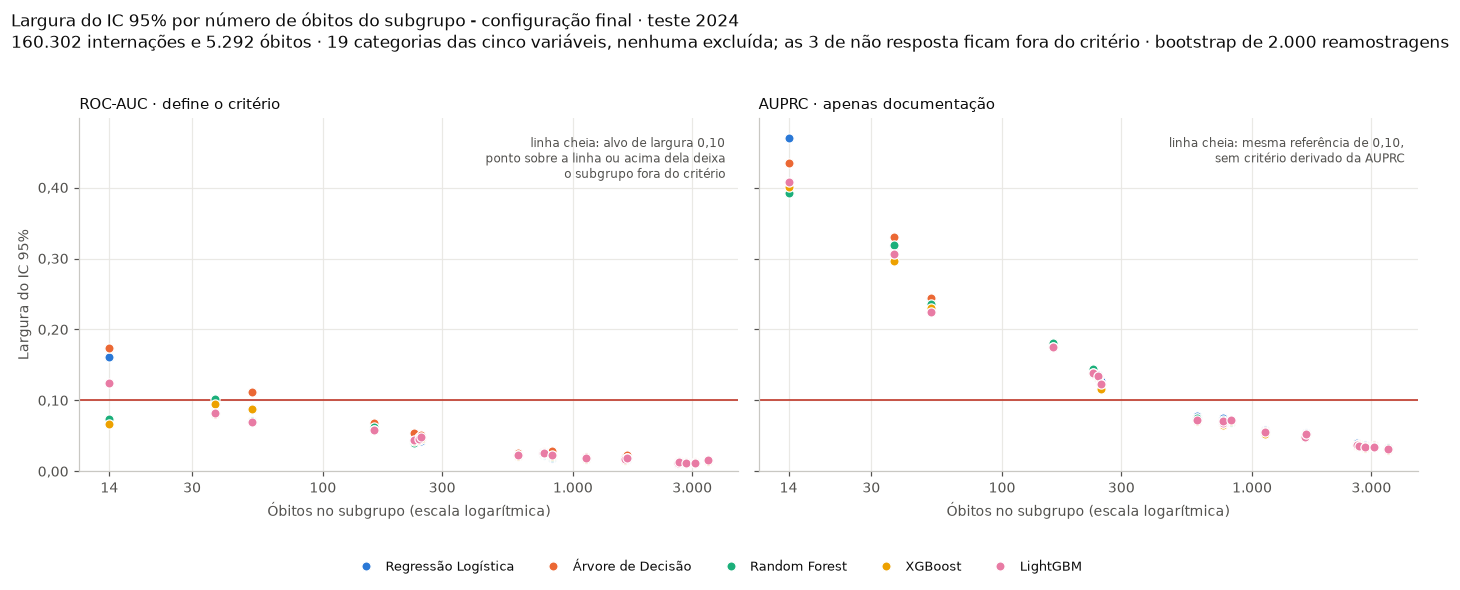

In [12]:
EVENTOS_MIN = int(df_largura_criterio['eventos'].min())
EVENTOS_MAX = int(df_largura_criterio['eventos'].max())
# Marcas fixas na década e na meia-década, para que 30 e 100 - os dois limiares de
# referência - fiquem legíveis no eixo.
MARCAS_X = sorted({EVENTOS_MIN} | {m for m in (30, 100, 300, 1000, 3000)
                   if EVENTOS_MIN * 1.3 <= m <= EVENTOS_MAX * 1.2})

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2), sharey=True)
for ax, nome in zip(axes, METRICAS_DISCRIMINACAO):
    rot = ROTULO_METRICA[nome]
    sub = df_largura_criterio[df_largura_criterio['metrica'] == rot]
    for algo, rotulo in ALGORITMOS.items():
        g = sub[sub['algoritmo'] == rotulo].sort_values('eventos')
        ax.plot(g['eventos'], g['largura_ic'], 'o', color=CORES_ALGO[algo], markersize=6,
                markeredgecolor='#ffffff', markeredgewidth=0.8, label=rotulo, zorder=3)
    ax.axhline(LARGURA_ALVO, color='#c0392b', linewidth=1.1, zorder=1)
    ax.set_xscale('log')
    ax.set_xlabel('Óbitos no subgrupo (escala logarítmica)')
    ax.set_title(f'{rot} · ' + ('define o critério' if nome == 'roc_auc'
                                else 'apenas documentação'), loc='left', fontsize=10)
    ax.grid(True, alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xticks(MARCAS_X)
    ax.set_xticklabels([n_(m) for m in MARCAS_X])
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())

axes[0].set_ylabel('Largura do IC 95%')
axes[0].set_ylim(0, max(0.12, float(df_largura_criterio['largura_ic'].max()) * 1.06))
axes[0].yaxis.set_major_formatter(eixo_virgula(2))
for ax, texto in zip(axes, [f'linha cheia: alvo de largura {v_(LARGURA_ALVO, 2)}\n'
                            f'ponto sobre a linha ou acima dela deixa\n'
                            f'o subgrupo fora do critério',
                            f'linha cheia: mesma referência de {v_(LARGURA_ALVO, 2)},\n'
                            f'sem critério derivado da AUPRC']):
    ax.text(0.98, 0.95, texto, transform=ax.transAxes, ha='right', va='top', fontsize=8,
            color=COR_TINTA)
handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0.08, 1, 0.87))
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.01), ncol=5,
           fontsize=8.5, handletextpad=0.5, columnspacing=2.0)
fig.suptitle(
    f'Largura do IC 95% por número de óbitos do subgrupo - configuração '
    f'{ROTULO_CONFIG[CONFIG_PRINCIPAL]} · teste {ANO_TESTE}\n'
    f'{n_(N_2024)} internações e {n_(EVENTOS_2024)} óbitos · '
    f'{len(df_criterio)} categorias das cinco variáveis, nenhuma excluída; as '
    f'{len(SUBGRUPOS_NAO_RESPOSTA)} de não resposta ficam fora do critério · bootstrap de '
    f'{n_(N_BOOTSTRAP)} reamostragens',
    x=0.006, y=0.995, ha='left', va='top', fontsize=11)
salvar_fig(fig, 'largura_ic_por_eventos.png')
plt.show()

Mede a largura que os limiares de referência de 30 e de 100 óbitos entregariam, pelos subgrupos que cada um admitiria.

In [13]:
linhas = []
for nome in METRICAS_DISCRIMINACAO:
    rot = ROTULO_METRICA[nome]
    sub = df_largura_criterio[df_largura_criterio['metrica'] == rot]
    for rotulo_algo in list(ALGORITMOS.values()) + ['agregado (cinco modelos)']:
        g = sub if rotulo_algo.startswith('agregado') else sub[sub['algoritmo'] == rotulo_algo]
        for limiar in EVENTOS_REFERENCIA:
            prox = g.iloc[(g['eventos'] - limiar).abs().argsort().iloc[0]]
            atende = g[g['eventos'] >= limiar]
            linhas.append({
                'metrica': rot, 'algoritmo': rotulo_algo,
                'limiar_de_referencia_eventos': limiar,
                'subgrupo_observado_mais_proximo': f'{prox["variavel"]} = {prox["subgrupo"]}',
                'eventos_do_subgrupo_mais_proximo': int(prox['eventos']),
                'largura_observada_no_subgrupo_mais_proximo': round(
                    float(prox['largura_ic']), 4),
                'subgrupos_admitidos_pelo_limiar': int(atende['subgrupo'].nunique()),
                'largura_mediana_entre_os_admitidos': round(
                    float(atende['largura_ic'].median()), 4),
                'largura_maxima_entre_os_admitidos': round(
                    float(atende['largura_ic'].max()), 4),
                'alvo_largura': LARGURA_ALVO,
                'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
            })

df_referencia = pd.DataFrame(linhas)
salvar_tab(df_referencia, 'largura_referencia_30_100.csv')
display(df_referencia[df_referencia['algoritmo'] == 'agregado (cinco modelos)'][
    ['metrica', 'limiar_de_referencia_eventos', 'subgrupo_observado_mais_proximo',
     'largura_observada_no_subgrupo_mais_proximo', 'subgrupos_admitidos_pelo_limiar',
     'largura_mediana_entre_os_admitidos', 'largura_maxima_entre_os_admitidos']].reset_index(
        drop=True))

for limiar in EVENTOS_REFERENCIA:
    for nome in METRICAS_DISCRIMINACAO:
        r = df_referencia[(df_referencia['metrica'] == ROTULO_METRICA[nome])
                          & (df_referencia['algoritmo'] == 'agregado (cinco modelos)')
                          & (df_referencia['limiar_de_referencia_eventos'] == limiar)].iloc[0]
        print(f'Limiar de {n_(limiar)} óbitos, {ROTULO_METRICA[nome]}: admite '
              f'{int(r["subgrupos_admitidos_pelo_limiar"])} dos {len(df_composicao)} '
              f'subgrupos, com largura observada de até '
              f'{v_(r["largura_maxima_entre_os_admitidos"])}')

[tabela] analysis/results_equidade/largura_referencia_30_100.csv  (24 linhas)


,metrica,limiar_de_referencia_eventos,subgrupo_observado_mais_proximo,largura_observada_no_subgrupo_mais_proximo,subgrupos_admitidos_pelo_limiar,largura_mediana_entre_os_admitidos,largura_maxima_entre_os_admitidos
0,ROC-AUC,30,Macrorregião = Norte,0.0802,18,0.0224,0.1111
1,ROC-AUC,100,Raça/cor = Amarela,0.0712,16,0.0204,0.0688
2,AUPRC,30,Macrorregião = Norte,0.3297,18,0.0685,0.3297
3,AUPRC,100,Raça/cor = Amarela,0.2365,16,0.0622,0.1805


Limiar de 30 óbitos, ROC-AUC: admite 18 dos 22 subgrupos, com largura observada de até 0,111
Limiar de 30 óbitos, AUPRC: admite 18 dos 22 subgrupos, com largura observada de até 0,330
Limiar de 100 óbitos, ROC-AUC: admite 16 dos 22 subgrupos, com largura observada de até 0,069
Limiar de 100 óbitos, AUPRC: admite 16 dos 22 subgrupos, com largura observada de até 0,180


Compara, entre ROC-AUC e AUPRC, a largura dos intervalos em cada faixa de tamanho de subgrupo.

In [14]:
faixas = [(0, 100), (100, 300), (300, 1000), (1000, np.inf)]
rotulo_faixa = {(0, 100): 'menos de 100 óbitos', (100, 300): '100 a 299 óbitos',
                (300, 1000): '300 a 999 óbitos', (1000, np.inf): '1.000 óbitos ou mais'}

linhas = []
for lo, hi in faixas:
    sel = df_largura_criterio[(df_largura_criterio['eventos'] >= lo)
                              & (df_largura_criterio['eventos'] < hi)]
    if sel.empty:
        continue
    linha = {'faixa_de_eventos': rotulo_faixa[(lo, hi)],
             'subgrupos': int(sel['subgrupo'].nunique()),
             'pares_subgrupo_modelo': len(sel) // len(METRICAS_DISCRIMINACAO)}
    for nome in METRICAS_DISCRIMINACAO:
        g = sel[sel['metrica'] == ROTULO_METRICA[nome]]
        linha[f'largura_mediana_{nome}'] = round(float(g['largura_ic'].median()), 4)
        linha[f'largura_maxima_{nome}'] = round(float(g['largura_ic'].max()), 4)
    linha['razao_mediana_auprc_sobre_roc_auc'] = round(
        linha['largura_mediana_auprc'] / linha['largura_mediana_roc_auc'], 2)
    linha['n_base_teste'] = N_2024
    linha['eventos_teste'] = EVENTOS_2024
    linhas.append(linha)

df_faixas = pd.DataFrame(linhas)
salvar_tab(df_faixas, 'largura_por_faixa_de_eventos.csv')
display(df_faixas.drop(columns=['n_base_teste', 'eventos_teste']))
print(f'\nA largura mediana do IC de AUPRC supera a de ROC-AUC em todas as faixas por um '
      f'fator de {v_(df_faixas["razao_mediana_auprc_sobre_roc_auc"].min(), 2)} a '
      f'{v_(df_faixas["razao_mediana_auprc_sobre_roc_auc"].max(), 2)}.')

[tabela] analysis/results_equidade/largura_por_faixa_de_eventos.csv  (4 linhas)


,faixa_de_eventos,subgrupos,pares_subgrupo_modelo,largura_mediana_roc_auc,largura_maxima_roc_auc,largura_mediana_auprc,largura_maxima_auprc,razao_mediana_auprc_sobre_roc_auc
0,menos de 100 óbitos,3,15,0.0872,0.1737,0.3174,0.4697,3.64
1,100 a 299 óbitos,4,20,0.0457,0.0688,0.1366,0.1805,2.99
2,300 a 999 óbitos,4,20,0.0243,0.0292,0.0710,0.0774,2.92
3,1.000 óbitos ou mais,8,40,0.0146,0.0226,0.0372,0.0589,2.55



A largura mediana do IC de AUPRC supera a de ROC-AUC em todas as faixas por um fator de 2,55 a 3,64.


Marca cada subgrupo com o atendimento ao critério de largura e fecha a tabela de equidade da configuração final.

In [15]:
chaves_composicao = list(zip(df_composicao['variavel'], df_composicao['subgrupo']))
df_composicao['atende_criterio'] = [atende_de(*ch) for ch in chaves_composicao]
df_composicao['largura_ic_roc_auc_maxima'] = [LARGURA_MAXIMA[ch] for ch in chaves_composicao]
df_composicao['criterio_largura_alvo'] = LARGURA_ALVO
salvar_tab(df_composicao, 'composicao_subgrupos_2024.csv')


def marcar(df_eq):
    df_eq = df_eq.copy()
    chaves = list(zip(df_eq['variavel'], df_eq['subgrupo']))
    df_eq['atende_criterio'] = [atende_de(*ch) for ch in chaves]
    df_eq['criterio_largura_alvo'] = LARGURA_ALVO
    ordem = ['variavel', 'subgrupo', 'atende_criterio', 'criterio_largura_alvo']
    return df_eq[ordem + [c for c in df_eq.columns if c not in ordem]]


df_equidade_principal = marcar(df_equidade_principal)
salvar_tab(df_equidade_principal, f'equidade_{CONFIG_PRINCIPAL}_2024.csv')

display(df_composicao.drop(columns=['n_base_teste', 'eventos_teste',
                                    'criterio_largura_alvo']))
print(f'\nCritério: {CRITERIO_TEXTO}. '
      f'{int((df_composicao["atende_criterio"] == "sim").sum())} dos {len(df_criterio)} '
      f'subgrupos entram no cálculo de disparidade, os mesmos nos cinco modelos. '
      f'Ficam fora por três motivos distintos, que a coluna separa: largura insuficiente '
      f'do intervalo, não resposta e não resposta estrutural. Os três são reportados com '
      f'n, óbitos, ponto e intervalo.')
print(df_composicao['atende_criterio'].value_counts().to_string())

[tabela] analysis/results_equidade/composicao_subgrupos_2024.csv  (22 linhas)
[tabela] analysis/results_equidade/equidade_corrigida_2024.csv  (110 linhas)


,variavel,subgrupo,n_base,eventos,categoria_de_nao_resposta,papel_na_variavel,prevalencia_pct,participacao_pct,atende_criterio,largura_ic_roc_auc_maxima
0,Faixa etária,menos de 15 anos,27707,160,não,nível da variável,0.58,17.28,sim,0.0688
1,Faixa etária,15 a 59 anos,85268,1648,não,nível da variável,1.93,53.19,sim,0.0226
2,Faixa etária,60 anos ou mais,47317,3484,não,nível da variável,7.36,29.52,sim,0.0166
3,Sexo,Feminino,87636,2665,não,nível da variável,3.04,54.67,sim,0.0152
4,Sexo,Masculino,72568,2625,não,nível da variável,3.62,45.27,sim,0.0137
5,Raça/cor,Branca,77295,2839,não,nível da variável,3.67,48.22,sim,0.0130
6,Raça/cor,Preta,5565,248,não,nível da variável,4.46,3.47,sim,0.0513
7,Raça/cor,Amarela,1729,52,não,nível da variável,3.01,1.08,não,0.1111
8,Raça/cor,Parda,55570,1623,não,nível da variável,2.92,34.67,sim,0.0195
9,Raça/cor,Indígena,410,14,não,nível da variável,3.41,0.26,não,0.1737



Critério: largura do IC 95% de ROC-AUC abaixo de 0,10 nos cinco modelos. 16 dos 19 subgrupos entram no cálculo de disparidade, os mesmos nos cinco modelos. Ficam fora por três motivos distintos, que a coluna separa: largura insuficiente do intervalo, não resposta e não resposta estrutural. Os três são reportados com n, óbitos, ponto e intervalo.
atende_criterio
sim                        16
não                         3
não resposta                2
não resposta estrutural     1


Mesma tabela de equidade na configuração sem critérios de gravidade, apenas como comparação.

In [16]:
t0 = time.perf_counter()
print(f'Configuração {ROTULO_CONFIG[CONFIG_COMPARACAO]} - todos os subgrupos')
df_equidade_comparacao = marcar(equidade(CONFIG_COMPARACAO))
salvar_tab(df_equidade_comparacao, f'equidade_{CONFIG_COMPARACAO}_2024.csv')
print(f'Concluído em {(time.perf_counter() - t0) / 60:.1f} min')

df_equidade = pd.concat([df_equidade_principal, df_equidade_comparacao], ignore_index=True)
resumo_cfg = (df_equidade[df_equidade['atende_criterio'] == 'sim']
              .groupby(['configuracao', 'variavel'], observed=True)['auprc']
              .agg(['min', 'max']).round(4))
resumo_cfg['amplitude'] = (resumo_cfg['max'] - resumo_cfg['min']).round(4)
display(resumo_cfg)

Configuração sem critérios de gravidade - todos os subgrupos


  Faixa etária   menos de 15 anos                   n= 27.707  óbitos=  160


  Faixa etária   15 a 59 anos                       n= 85.268  óbitos=1.648


  Faixa etária   60 anos ou mais                    n= 47.317  óbitos=3.484


  Sexo           Feminino                           n= 87.636  óbitos=2.665


...

  Macrorregião   Nordeste                           n= 13.298  óbitos=  231


  Macrorregião   Sudeste                            n= 82.625  óbitos=3.074


  Macrorregião   Sul                                n= 36.378  óbitos=1.126


  Macrorregião   Centro-Oeste                       n= 25.364  óbitos=  824
[tabela] analysis/results_equidade/equidade_notificacao_2024.csv  (110 linhas)
Concluído em 6.8 min


min     max  amplitude
configuracao               variavel                               
final                      Escolaridade  0.5668  0.7071     0.1403
                           Faixa etária  0.4179  0.6639     0.2460
                           Macrorregião  0.5095  0.6793     0.1698
                           Raça/cor      0.5604  0.6683     0.1079
                           Sexo          0.5821  0.6465     0.0644
sem critérios de gravidade Escolaridade  0.1653  0.3402     0.1749
                           Faixa etária  0.0591  0.3326     0.2735
                           Macrorregião  0.1765  0.3371     0.1606
                           Raça/cor      0.2106  0.3104     0.0998
                           Sexo          0.2190  0.3084     0.0894

Quantifica a disparidade por variável e modelo na configuração final, apenas entre os subgrupos que atendem ao critério.

In [17]:
def disparidades(df_eq):
    '''Diferença entre AUPRC máxima e mínima e diferença de sensibilidade entre os
    subgrupos extremos, restritas aos subgrupos que atendem ao critério.'''
    linhas = []
    elegivel = df_eq[df_eq['atende_criterio'] == 'sim']
    for (cfg, rotulo_var, algo), g in elegivel.groupby(
            ['configuracao', 'variavel', 'algoritmo'], observed=True):
        if len(g) < 2:
            print(f'  {rotulo_var} / {algo}: {len(g)} subgrupo elegível, disparidade não '
                  f'definida')
            continue
        i_max, i_min = g['auprc'].idxmax(), g['auprc'].idxmin()
        s_max, s_min = g['sensibilidade'].idxmax(), g['sensibilidade'].idxmin()
        linhas.append({
            'configuracao': cfg, 'variavel': rotulo_var, 'algoritmo': algo,
            'criterio_largura_alvo': LARGURA_ALVO,
            'n_subgrupos_elegiveis': len(g),
            'n_subgrupos_da_variavel': len(SUBGRUPOS_VALIDOS[rotulo_var]),
            'n_subgrupos_de_nao_resposta': sum(
                1 for s in TODOS_SUBGRUPOS[rotulo_var]
                if (rotulo_var, s) in NAO_RESPOSTA
                and (rotulo_var, s) not in NAO_RESPOSTA_ESTRUTURAL),
            'n_subgrupos_de_nao_resposta_estrutural': sum(
                1 for s in TODOS_SUBGRUPOS[rotulo_var]
                if (rotulo_var, s) in NAO_RESPOSTA_ESTRUTURAL),
            'auprc_maxima': round(float(g.loc[i_max, 'auprc']), 4),
            'subgrupo_auprc_maxima': g.loc[i_max, 'subgrupo'],
            'auprc_minima': round(float(g.loc[i_min, 'auprc']), 4),
            'subgrupo_auprc_minima': g.loc[i_min, 'subgrupo'],
            'disparidade_auprc': round(float(g.loc[i_max, 'auprc'] - g.loc[i_min, 'auprc']), 4),
            'roc_auc_maxima': round(float(g['roc_auc'].max()), 4),
            'roc_auc_minima': round(float(g['roc_auc'].min()), 4),
            'disparidade_roc_auc': round(float(g['roc_auc'].max() - g['roc_auc'].min()), 4),
            'sensibilidade_no_subgrupo_auprc_maxima':
                round(float(g.loc[i_max, 'sensibilidade']), 4),
            'sensibilidade_no_subgrupo_auprc_minima':
                round(float(g.loc[i_min, 'sensibilidade']), 4),
            'diferenca_sensibilidade_entre_extremos_auprc':
                round(float(g.loc[i_max, 'sensibilidade'] - g.loc[i_min, 'sensibilidade']), 4),
            'sensibilidade_maxima': round(float(g.loc[s_max, 'sensibilidade']), 4),
            'subgrupo_sensibilidade_maxima': g.loc[s_max, 'subgrupo'],
            'sensibilidade_minima': round(float(g.loc[s_min, 'sensibilidade']), 4),
            'subgrupo_sensibilidade_minima': g.loc[s_min, 'subgrupo'],
            'disparidade_sensibilidade': round(
                float(g.loc[s_max, 'sensibilidade'] - g.loc[s_min, 'sensibilidade']), 4),
            'eventos_menor_subgrupo_elegivel': int(g['eventos'].min()),
            'largura_ic_roc_auc_maxima_entre_os_elegiveis': round(
                float(g['largura_ic_roc_auc'].max()), 4),
            'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
        })
    df = pd.DataFrame(linhas)
    df['_a'] = df['algoritmo'].map(ORDEM_ALGO)
    df['_v'] = df['variavel'].map({r: i for i, r in enumerate(VARIAVEIS)})
    df['_c'] = df['configuracao'].map(ORDEM_CONFIG)
    return (df.sort_values(['_c', '_v', '_a']).drop(columns=['_a', '_v', '_c'])
            .reset_index(drop=True))


df_disparidade = disparidades(df_equidade_principal)
salvar_tab(df_disparidade, 'disparidade_por_variavel.csv')

display(df_disparidade[['variavel', 'algoritmo', 'n_subgrupos_elegiveis', 'auprc_maxima',
                        'subgrupo_auprc_maxima', 'auprc_minima', 'subgrupo_auprc_minima',
                        'disparidade_auprc', 'disparidade_sensibilidade']])
print(f'\nDisparidade de AUPRC na configuração {ROTULO_CONFIG[CONFIG_PRINCIPAL]}: mediana '
      f'{v_(df_disparidade["disparidade_auprc"].median(), 4)}, máxima '
      f'{v_(df_disparidade["disparidade_auprc"].max(), 4)}')
print(f'Disparidade de sensibilidade: mediana '
      f'{v_(df_disparidade["disparidade_sensibilidade"].median(), 4)}, máxima '
      f'{v_(df_disparidade["disparidade_sensibilidade"].max(), 4)}')

[tabela] analysis/results_equidade/disparidade_por_variavel.csv  (25 linhas)


,variavel,algoritmo,n_subgrupos_elegiveis,auprc_maxima,subgrupo_auprc_maxima,auprc_minima,subgrupo_auprc_minima,disparidade_auprc,disparidade_sensibilidade
0,Faixa etária,Regressão Logística,3,0.6479,60 anos ou mais,0.4179,menos de 15 anos,0.2300,0.1184
1,Faixa etária,Árvore de Decisão,3,0.5998,60 anos ou mais,0.4419,menos de 15 anos,0.1579,0.1961
2,Faixa etária,Random Forest,3,0.6476,60 anos ou mais,0.4904,menos de 15 anos,0.1572,0.1134
3,Faixa etária,XGBoost,3,0.6639,60 anos ou mais,0.5069,menos de 15 anos,0.1570,0.0931
4,Faixa etária,LightGBM,3,0.6585,60 anos ou mais,0.5030,menos de 15 anos,0.1555,0.1048
5,Sexo,Regressão Logística,2,0.6232,Masculino,0.6194,Feminino,0.0038,0.0015
6,Sexo,Árvore de Decisão,2,0.5836,Masculino,0.5821,Feminino,0.0015,0.0015
7,Sexo,Random Forest,2,0.6336,Feminino,0.6301,Masculino,0.0035,0.0139
8,Sexo,XGBoost,2,0.6465,Feminino,0.6428,Masculino,0.0037,0.0001
9,Sexo,LightGBM,2,0.6459,Feminino,0.6380,Masculino,0.0079,0.0170



Disparidade de AUPRC na configuração final: mediana 0,0758, máxima 0,2300
Disparidade de sensibilidade: mediana 0,0744, máxima 0,1961


Confronta o padrão publicado, de pior desempenho em menores de 15 anos e no Nordeste, com o que se observa depois da calibração e da mudança de limiar.

In [18]:
PADRAO_PUBLICADO = {'Faixa etária': 'menos de 15 anos', 'Macrorregião': 'Nordeste'}

linhas = []
df_eq = df_equidade_principal
for rotulo_var, sg_publicado in PADRAO_PUBLICADO.items():
    for algo, rotulo in ALGORITMOS.items():
        g = df_eq[(df_eq['variavel'] == rotulo_var) & (df_eq['algoritmo'] == rotulo)
                  & (df_eq['atende_criterio'] == 'sim')]
        alvo = df_eq[(df_eq['variavel'] == rotulo_var) & (df_eq['algoritmo'] == rotulo)
                     & (df_eq['subgrupo'] == sg_publicado)].iloc[0]
        pior = g.loc[g['auprc'].idxmin()]
        no_criterio = alvo['atende_criterio'] == 'sim'
        posicao = (f'{int((g["auprc"] < alvo["auprc"]).sum()) + 1}º de {len(g)} '
                   f'(do menor para o maior AUPRC)') if no_criterio else \
                  'fora do critério, não entra no ranqueamento'
        linhas.append({
            'configuracao': ROTULO_CONFIG[CONFIG_PRINCIPAL], 'variavel': rotulo_var,
            'subgrupo_publicado_como_pior': sg_publicado, 'algoritmo': rotulo,
            'n_base': int(alvo['n_base']), 'eventos': int(alvo['eventos']),
            'atende_criterio': alvo['atende_criterio'],
            'criterio_largura_alvo': LARGURA_ALVO,
            'auprc_subgrupo_publicado': alvo['auprc'],
            'auprc_ic_inf': alvo['auprc_ic_inf'], 'auprc_ic_sup': alvo['auprc_ic_sup'],
            'roc_auc_subgrupo_publicado': alvo['roc_auc'],
            'roc_auc_ic_inf': alvo['roc_auc_ic_inf'], 'roc_auc_ic_sup': alvo['roc_auc_ic_sup'],
            'posicao_do_subgrupo': posicao,
            'subgrupo_com_menor_auprc_entre_os_elegiveis': pior['subgrupo'],
            'auprc_menor_entre_os_elegiveis': pior['auprc'],
            'diferenca_para_o_menor': round(float(alvo['auprc'] - pior['auprc']), 4),
            'padrao_mantido': ('sim' if pior['subgrupo'] == sg_publicado else 'não')
                              if no_criterio else 'não verificável no critério',
            'sensibilidade_subgrupo_publicado': alvo['sensibilidade'],
            'sensibilidade_ic_inf': alvo['sensibilidade_ic_inf'],
            'sensibilidade_ic_sup': alvo['sensibilidade_ic_sup'],
            'vpp_subgrupo_publicado': alvo['vpp'],
            'n_base_teste': N_2024, 'eventos_teste': EVENTOS_2024,
        })

df_padrao = pd.DataFrame(linhas)
df_padrao['_a'] = df_padrao['algoritmo'].map(ORDEM_ALGO)
df_padrao = (df_padrao.sort_values(['variavel', '_a']).drop(columns='_a')
             .reset_index(drop=True))
salvar_tab(df_padrao, 'comparacao_padrao_publicado.csv')
display(df_padrao[['variavel', 'subgrupo_publicado_como_pior', 'algoritmo', 'eventos',
                   'atende_criterio', 'auprc_subgrupo_publicado',
                   'subgrupo_com_menor_auprc_entre_os_elegiveis',
                   'auprc_menor_entre_os_elegiveis', 'padrao_mantido']])

for rotulo_var, sg in PADRAO_PUBLICADO.items():
    sub = df_padrao[df_padrao['variavel'] == rotulo_var]
    mantidos = int((sub['padrao_mantido'] == 'sim').sum())
    print(f'{rotulo_var} / {sg}: atende ao critério: '
          f'{sub["atende_criterio"].iloc[0]}; continua o menor AUPRC em {mantidos} '
          f'dos {len(sub)} modelos')

[tabela] analysis/results_equidade/comparacao_padrao_publicado.csv  (10 linhas)


,variavel,subgrupo_publicado_como_pior,algoritmo,eventos,atende_criterio,auprc_subgrupo_publicado,subgrupo_com_menor_auprc_entre_os_elegiveis,auprc_menor_entre_os_elegiveis,padrao_mantido
0,Faixa etária,menos de 15 anos,Regressão Logística,160,sim,0.4179,menos de 15 anos,0.4179,sim
1,Faixa etária,menos de 15 anos,Árvore de Decisão,160,sim,0.4419,menos de 15 anos,0.4419,sim
2,Faixa etária,menos de 15 anos,Random Forest,160,sim,0.4904,menos de 15 anos,0.4904,sim
3,Faixa etária,menos de 15 anos,XGBoost,160,sim,0.5069,menos de 15 anos,0.5069,sim
4,Faixa etária,menos de 15 anos,LightGBM,160,sim,0.5030,menos de 15 anos,0.5030,sim
5,Macrorregião,Nordeste,Regressão Logística,231,sim,0.5564,Nordeste,0.5564,sim
6,Macrorregião,Nordeste,Árvore de Decisão,231,sim,0.5095,Nordeste,0.5095,sim
7,Macrorregião,Nordeste,Random Forest,231,sim,0.5626,Nordeste,0.5626,sim
8,Macrorregião,Nordeste,XGBoost,231,sim,0.5728,Nordeste,0.5728,sim
9,Macrorregião,Nordeste,LightGBM,231,sim,0.5760,Nordeste,0.5760,sim


Faixa etária / menos de 15 anos: atende ao critério: sim; continua o menor AUPRC em 5 dos 5 modelos
Macrorregião / Nordeste: atende ao critério: sim; continua o menor AUPRC em 5 dos 5 modelos


Figura: AUPRC por subgrupo na configuração final, um painel por variável, com marca aberta nos subgrupos fora do critério.

[figura] analysis/plots/equidade/equidade_auprc_corrigida.png


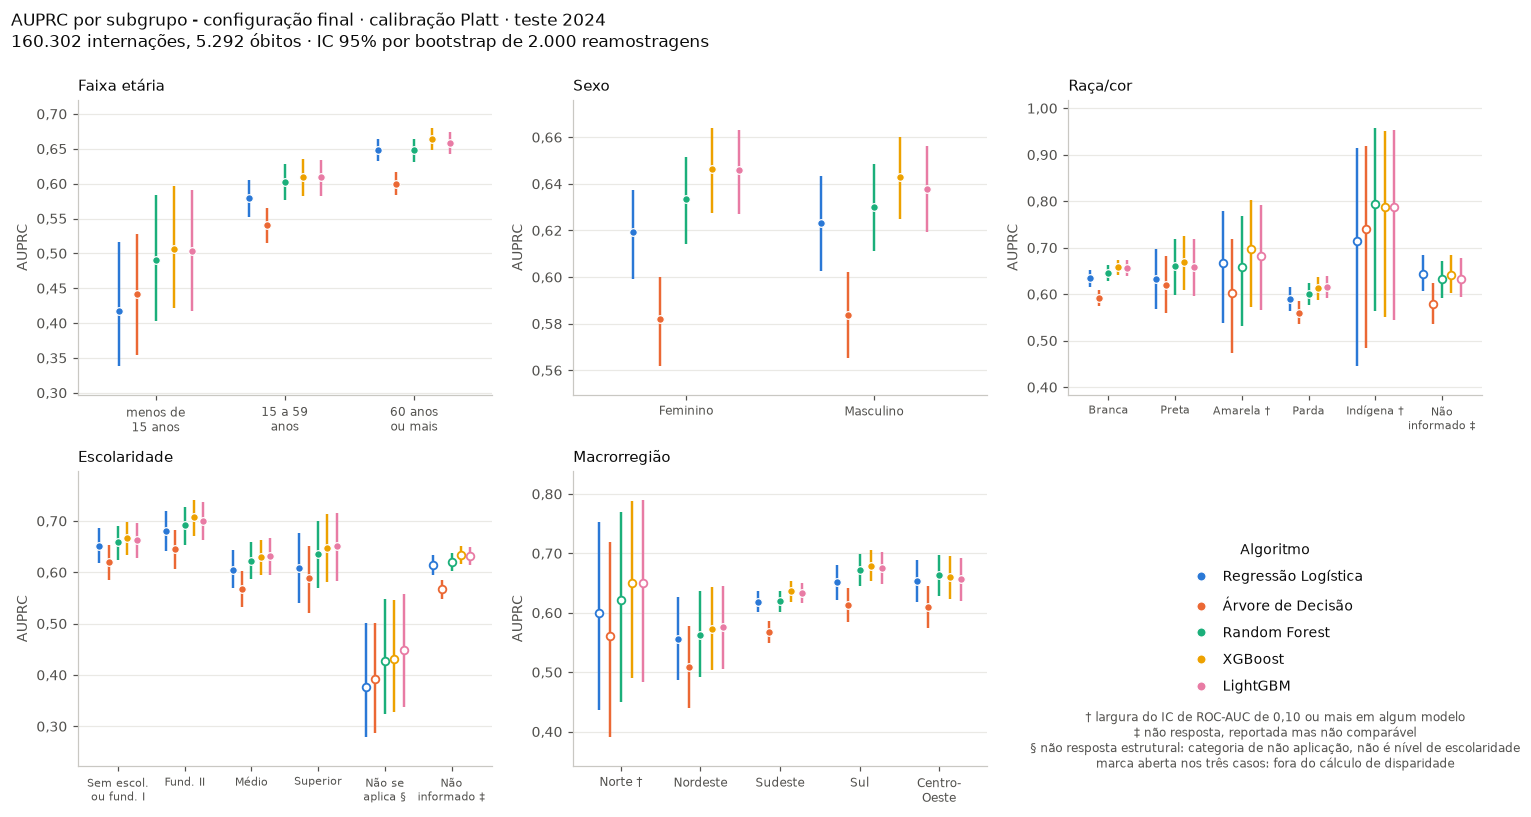

In [19]:
def sufixo_marca(rotulo_var, subgrupo):
    '''Marca do subgrupo no eixo, uma por motivo de ficar fora do cálculo.

    São três motivos distintos: † largura insuficiente do intervalo, ‡ não resposta, e
    § não resposta estrutural, a categoria que não é um nível da variável. A marca diz
    qual é, e a marca aberta no ponto diz apenas que o subgrupo está fora do cálculo.
    '''
    if (rotulo_var, subgrupo) in NAO_RESPOSTA_ESTRUTURAL:
        return ' §'
    if (rotulo_var, subgrupo) in SUBGRUPOS_NAO_RESPOSTA:
        return ' ‡'
    return ' †' if (rotulo_var, subgrupo) in SUBGRUPOS_FORA else ''


def painel_por_subgrupo(df_eq, metrica, titulo, arquivo, referencia=None):
    '''Ponto e intervalo por modelo em cada subgrupo. A cor identifica o algoritmo e
    a marca aberta identifica o subgrupo que não atende ao critério.'''
    fig, axes = plt.subplots(2, 3, figsize=(14.2, 7.4))
    eixos = axes.ravel()
    desloc = np.linspace(-0.28, 0.28, len(ALGORITMOS))

    for ax, rotulo_var in zip(eixos, VARIAVEIS):
        sub = df_eq[df_eq['variavel'] == rotulo_var]
        subgrupos = TODOS_SUBGRUPOS[rotulo_var]
        x = np.arange(len(subgrupos))
        for i, (algo, rotulo) in enumerate(ALGORITMOS.items()):
            g = sub[sub['algoritmo'] == rotulo].set_index('subgrupo')
            for j, s in enumerate(subgrupos):
                val = float(g.loc[s, metrica])
                lo = float(g.loc[s, f'{metrica}_ic_inf'])
                hi = float(g.loc[s, f'{metrica}_ic_sup'])
                dentro = sufixo_marca(rotulo_var, s) == ''
                # O IC percentil pode cair de um lado só do ponto em subgrupos pequenos;
                # o traço é cortado em zero para não virar comprimento negativo.
                ax.errorbar(x[j] + desloc[i], val,
                            yerr=[[max(val - lo, 0)], [max(hi - val, 0)]], fmt='o',
                            color=CORES_ALGO[algo], markersize=5, linewidth=1.6, capsize=0,
                            markerfacecolor=CORES_ALGO[algo] if dentro else '#ffffff',
                            markeredgecolor='#ffffff' if dentro else CORES_ALGO[algo],
                            markeredgewidth=0.8 if dentro else 1.2)
        if referencia is not None:
            ax.axhline(referencia, color=COR_REF, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
        rotulos = [ROTULO_SUBGRUPO_CURTO.get(s, s) + sufixo_marca(rotulo_var, s)
                   for s in subgrupos]
        ax.set_xticks(x)
        # Seis posições num painel de um terço da largura não cabem no corpo de oito:
        # com a escolaridade em 4 níveis mais 2 categorias reportadas, os rótulos colidiam.
        ax.set_xticklabels(rotulos, fontsize=8 if len(subgrupos) <= 5 else 7)
        ax.set_xlim(-0.6, len(subgrupos) - 0.4)
        ax.margins(y=0.12)
        ax.set_title(rotulo_var, loc='left', fontsize=10)
        ax.set_ylabel(ROTULO_METRICA[metrica])
        ax.grid(True, axis='y', alpha=0.9, zorder=0)
        ax.set_axisbelow(True)
        ajustar_eixo(ax, 'y')

    eixos[-1].axis('off')
    # Marcas da legenda montadas à parte: a marca do painel varia com o critério e
    # não deve definir como o algoritmo aparece na legenda.
    handles = [mpl.lines.Line2D([], [], color=CORES_ALGO[algo], marker='o', linestyle='none',
                                markersize=6, markeredgecolor='#ffffff', markeredgewidth=0.8)
               for algo in ALGORITMOS]
    labels = list(ALGORITMOS.values())
    eixos[-1].legend(handles, labels, loc='center', fontsize=9, handletextpad=0.6,
                     title='Algoritmo', title_fontsize=9, labelspacing=0.9)
    eixos[-1].text(0.5, 0.085, f'† largura do IC de ROC-AUC de {v_(LARGURA_ALVO, 2)} ou '
                               f'mais em algum modelo\n‡ não resposta, reportada mas não '
                               f'comparável\n§ não resposta estrutural: categoria de não '
                               f'aplicação, não é nível de escolaridade\nmarca aberta nos '
                               f'três casos: '
                               f'fora do cálculo de disparidade',
                   ha='center', va='center', fontsize=8, color=COR_TINTA)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.suptitle(titulo, x=0.006, y=0.995, ha='left', va='top', fontsize=11)
    salvar_fig(fig, arquivo)
    plt.show()


painel_por_subgrupo(
    df_equidade_principal, 'auprc',
    f'AUPRC por subgrupo - configuração {ROTULO_CONFIG[CONFIG_PRINCIPAL]} · calibração '
    f'{CALIBRACAO} · teste {ANO_TESTE}\n{n_(N_2024)} internações, {n_(EVENTOS_2024)} óbitos · '
    f'IC 95% por bootstrap de {n_(N_BOOTSTRAP)} reamostragens',
    f'equidade_auprc_{CONFIG_PRINCIPAL}.png')

Figura: ROC-AUC por subgrupo, a métrica que sustenta o critério de inclusão.

[figura] analysis/plots/equidade/equidade_roc_auc_corrigida.png


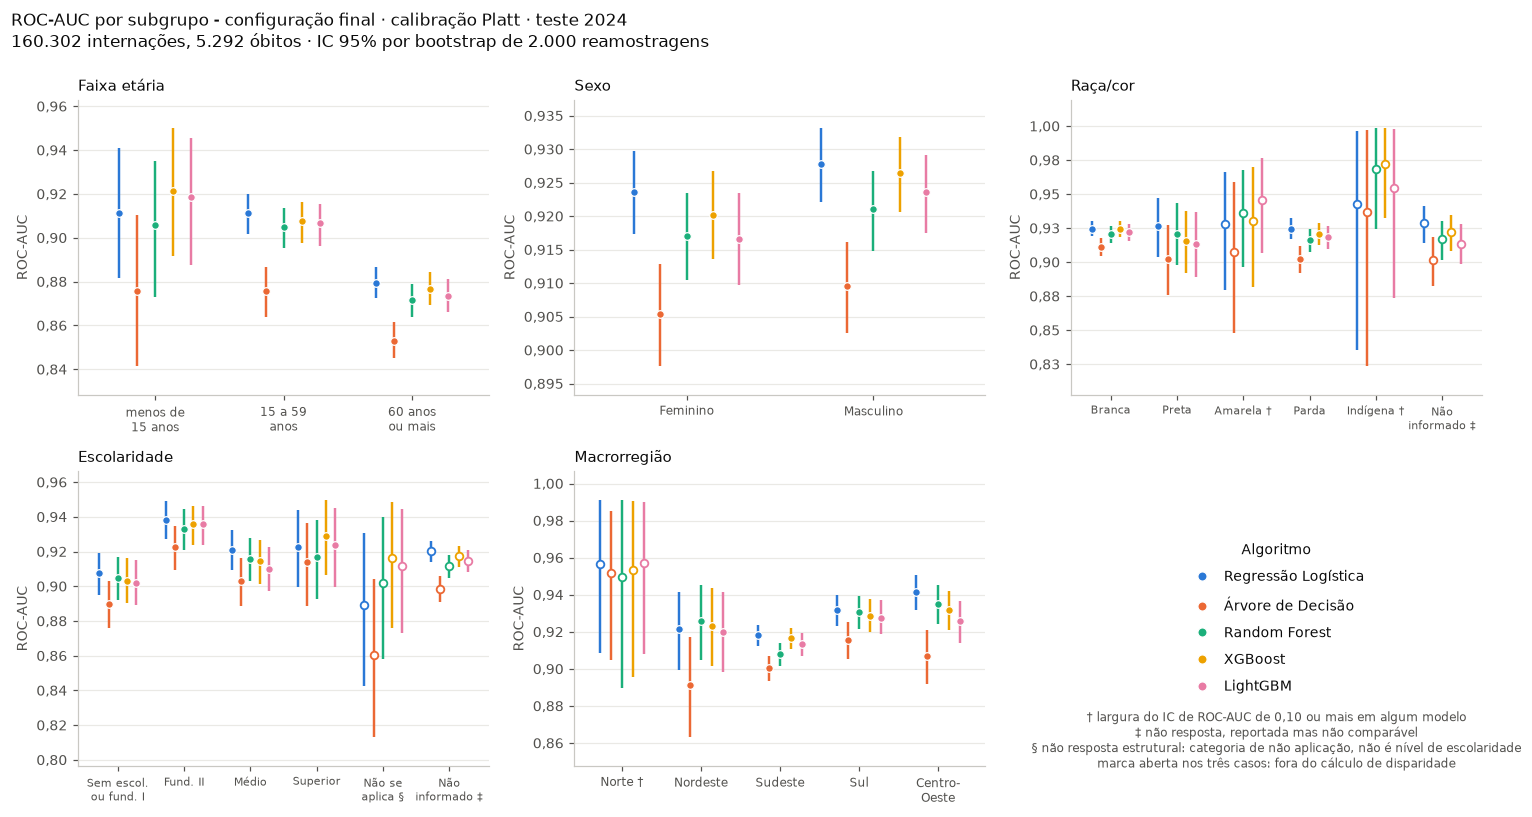

In [20]:
painel_por_subgrupo(
    df_equidade_principal, 'roc_auc',
    f'ROC-AUC por subgrupo - configuração {ROTULO_CONFIG[CONFIG_PRINCIPAL]} · calibração '
    f'{CALIBRACAO} · teste {ANO_TESTE}\n{n_(N_2024)} internações, {n_(EVENTOS_2024)} óbitos · '
    f'IC 95% por bootstrap de {n_(N_BOOTSTRAP)} reamostragens',
    f'equidade_roc_auc_{CONFIG_PRINCIPAL}.png')

Figura: sensibilidade por subgrupo, com a linha do alvo de 0,80 que o limiar persegue.

[figura] analysis/plots/equidade/equidade_sensibilidade_corrigida.png


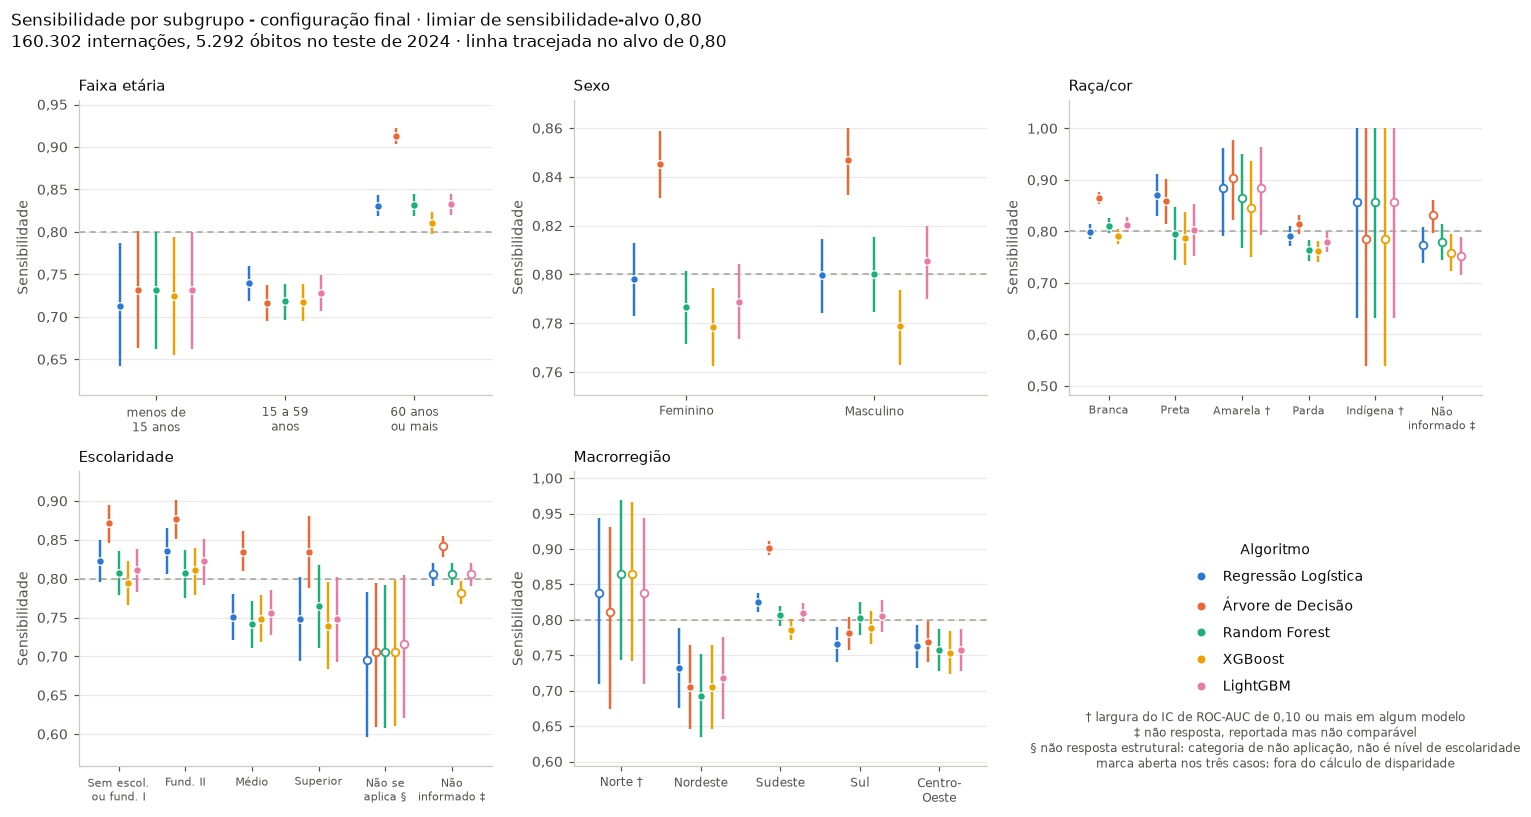

In [21]:
painel_por_subgrupo(
    df_equidade_principal, 'sensibilidade',
    f'Sensibilidade por subgrupo - configuração {ROTULO_CONFIG[CONFIG_PRINCIPAL]} · limiar de '
    f'sensibilidade-alvo {v_(SENS_ALVO, 2)}\n{n_(N_2024)} internações, {n_(EVENTOS_2024)} '
    f'óbitos no teste de {ANO_TESTE} · linha tracejada no alvo de {v_(SENS_ALVO, 2)}',
    f'equidade_sensibilidade_{CONFIG_PRINCIPAL}.png', referencia=SENS_ALVO)

Avalia os cinco modelos da configuração final em 2024 e em 2025, com o mesmo limiar e sem nenhum reajuste.

In [22]:
chaves_principal = [chave_de(algo, CONFIG_PRINCIPAL) for algo in ALGORITMOS]
lim_principal = {k: LIMIARES[k] for k in chaves_principal}

t0 = time.perf_counter()
ponto_ano, dist_ano = {}, {}
for ano, y_ano in ((ANO_TESTE, Y_2024), (ANO_EXTERNO, Y_2025)):
    ponto_ano[ano], dist_ano[ano] = distribuicoes(
        y_ano, {k: probabilidades[k][ano] for k in chaves_principal}, lim_principal)
    print(f'{ano}: {n_(len(y_ano))} internações, {n_(int(y_ano.sum()))} óbitos - '
          f'{time.perf_counter() - t0:.0f}s acumulados')

linhas = []
for algo, rotulo in ALGORITMOS.items():
    k = chave_de(algo, CONFIG_PRINCIPAL)
    linha = {
        'algoritmo': rotulo, 'configuracao': ROTULO_CONFIG[CONFIG_PRINCIPAL],
        'versao': VERSAO_SELECIONADA[(ROTULO_CONFIG[CONFIG_PRINCIPAL], rotulo)],
        'calibracao': CALIBRACAO, 'limiar': round(LIMIARES[k], 6),
        'n_base_2024': N_2024, 'eventos_2024': EVENTOS_2024,
        'prevalencia_2024_pct': round(PREV_2024 * 100, 3),
        'n_base_2025': N_2025, 'eventos_2025': EVENTOS_2025,
        'prevalencia_2025_pct': round(PREV_2025 * 100, 3),
    }
    for nome in METRICAS_ESTABILIDADE:
        casas = 5 if nome == 'brier' else 4
        for ano in (ANO_TESTE, ANO_EXTERNO):
            lo, hi = ic95(dist_ano[ano][k][nome])
            linha[f'{nome}_{ano}'] = round(ponto_ano[ano][k][nome], casas)
            linha[f'{nome}_{ano}_ic_inf'] = round(lo, casas)
            linha[f'{nome}_{ano}_ic_sup'] = round(hi, casas)
        # Anos são amostras independentes: a réplica b de 2025 menos a réplica b de 2024
        # dá a distribuição da diferença sem supor pareamento entre as bases.
        delta = (dist_ano[ANO_EXTERNO][k][nome].to_numpy()
                 - dist_ano[ANO_TESTE][k][nome].to_numpy())
        lo, hi = ic95(delta)
        linha[f'diferenca_{nome}'] = round(
            ponto_ano[ANO_EXTERNO][k][nome] - ponto_ano[ANO_TESTE][k][nome], casas)
        linha[f'diferenca_{nome}_ic_inf'] = round(lo, casas)
        linha[f'diferenca_{nome}_ic_sup'] = round(hi, casas)
        linha[f'diferenca_{nome}_exclui_zero'] = 'sim' if lo * hi > 0 else 'não'
    linhas.append(linha)

df_estabilidade = pd.DataFrame(linhas)
salvar_tab(df_estabilidade, 'estabilidade_2024_2025.csv')

vis = df_estabilidade[['algoritmo', 'versao']].copy()
for nome in METRICAS_ESTABILIDADE:
    casas = 5 if nome == 'brier' else 3
    vis[f'{ROTULO_METRICA[nome]} {ANO_TESTE}'] = df_estabilidade.apply(
        lambda r, m=nome, c=casas: f'{v_(r[f"{m}_{ANO_TESTE}"], c)}', axis=1)
    vis[f'{ROTULO_METRICA[nome]} {ANO_EXTERNO}'] = df_estabilidade.apply(
        lambda r, m=nome, c=casas: f'{v_(r[f"{m}_{ANO_EXTERNO}"], c)}', axis=1)
    vis[f'Δ {ROTULO_METRICA[nome]}'] = df_estabilidade.apply(
        lambda r, m=nome, c=casas: f'{v_(r[f"diferenca_{m}"], c)} '
                                   f'{ic_(r[f"diferenca_{m}_ic_inf"], r[f"diferenca_{m}_ic_sup"], c)}',
        axis=1)
display(vis[['algoritmo', 'versao'] + [c for c in vis.columns if 'Sensibilidade' in c]])
display(vis[['algoritmo'] + [c for c in vis.columns if 'Brier' in c]])

2024: 160.302 internações, 5.292 óbitos - 73s acumulados


2025: 63.066 internações, 1.530 óbitos - 102s acumulados
[tabela] analysis/results_equidade/estabilidade_2024_2025.csv  (5 linhas)


,algoritmo,versao,Sensibilidade 2024,Sensibilidade 2025,Δ Sensibilidade
0,Regressão Logística,otimizada,"0,799","0,790","-0,009 [-0,031; 0,014]"
1,Árvore de Decisão,otimizada,"0,846","0,854","0,007 [-0,013; 0,027]"
2,Random Forest,otimizada,"0,793","0,780","-0,014 [-0,037; 0,010]"
3,XGBoost,otimizada,"0,779","0,763","-0,015 [-0,038; 0,008]"
4,LightGBM,otimizada,"0,797","0,777","-0,020 [-0,043; 0,003]"


,algoritmo,Brier Score 2024,Brier Score 2025,Δ Brier Score,Brier Skill Score 2024,Brier Skill Score 2025,Δ Brier Skill Score
0,Regressão Logística,"0,02053","0,01680","-0,00373 [-0,00463; -0,00288]","0,357","0,290","-0,067 [-0,091; -0,042]"
1,Árvore de Decisão,"0,02083","0,01672","-0,00411 [-0,00504; -0,00322]","0,347","0,294","-0,054 [-0,076; -0,031]"
2,Random Forest,"0,01786","0,01469","-0,00317 [-0,00412; -0,00223]","0,441","0,379","-0,061 [-0,092; -0,030]"
3,XGBoost,"0,01963","0,01600","-0,00363 [-0,00454; -0,00276]","0,385","0,324","-0,061 [-0,086; -0,035]"
4,LightGBM,"0,01931","0,01592","-0,00340 [-0,00430; -0,00252]","0,395","0,328","-0,067 [-0,094; -0,041]"


Figura: diferença de cada métrica entre 2025 e 2024, com IC 95% e a linha do zero.

[figura] analysis/plots/equidade/estabilidade_diferencas.png


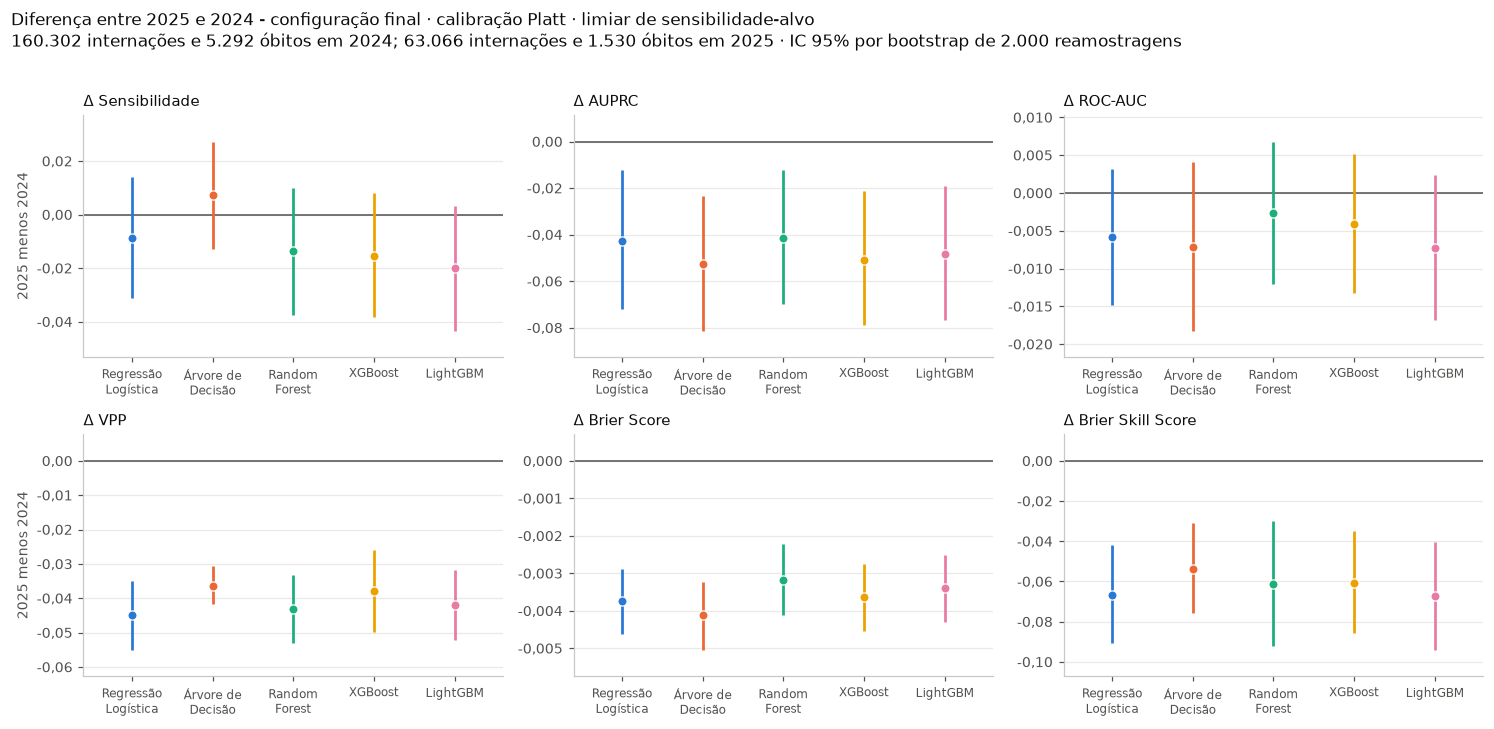

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(13.6, 6.6))
x = np.arange(len(ALGORITMOS))
for ax, nome in zip(axes.ravel(), METRICAS_ESTABILIDADE):
    for i, (algo, rotulo) in enumerate(ALGORITMOS.items()):
        r = df_estabilidade[df_estabilidade['algoritmo'] == rotulo].iloc[0]
        val = r[f'diferenca_{nome}']
        lo, hi = r[f'diferenca_{nome}_ic_inf'], r[f'diferenca_{nome}_ic_sup']
        ax.errorbar([i], [val], yerr=[[max(val - lo, 0)], [max(hi - val, 0)]], fmt='o',
                    color=CORES_ALGO[algo], markersize=6, linewidth=1.8, capsize=0,
                    markeredgecolor='#ffffff', markeredgewidth=0.8, label=rotulo)
    ax.axhline(0, color=COR_TINTA, linewidth=1, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(list(ROTULO_ALGO_CURTO.values()), fontsize=8)
    ax.set_xlim(-0.6, len(ALGORITMOS) - 0.4)
    ax.margins(y=0.14)
    ax.set_title(f'Δ {ROTULO_METRICA[nome]}', loc='left', fontsize=10)
    ax.grid(True, axis='y', alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    ajustar_eixo(ax, 'y', casas_min=3 if nome == 'brier' else 2)
axes[0, 0].set_ylabel(f'{ANO_EXTERNO} menos {ANO_TESTE}')
axes[1, 0].set_ylabel(f'{ANO_EXTERNO} menos {ANO_TESTE}')
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.suptitle(
    f'Diferença entre {ANO_EXTERNO} e {ANO_TESTE} - configuração '
    f'{ROTULO_CONFIG[CONFIG_PRINCIPAL]} · calibração {CALIBRACAO} · limiar de '
    f'sensibilidade-alvo\n{n_(N_2024)} internações e {n_(EVENTOS_2024)} óbitos em {ANO_TESTE}; '
    f'{n_(N_2025)} internações e {n_(EVENTOS_2025)} óbitos em {ANO_EXTERNO} · IC 95% por '
    f'bootstrap de {n_(N_BOOTSTRAP)} reamostragens',
    x=0.006, y=0.995, ha='left', va='top', fontsize=11)
salvar_fig(fig, 'estabilidade_diferencas.png')
plt.show()

Figura e tabela: curva de calibração por decil de risco predito em 2024 e em 2025.

[tabela] analysis/results_equidade/curva_calibracao_por_decil.csv  (91 linhas)


[figura] analysis/plots/equidade/calibracao_decis_2024_2025.png


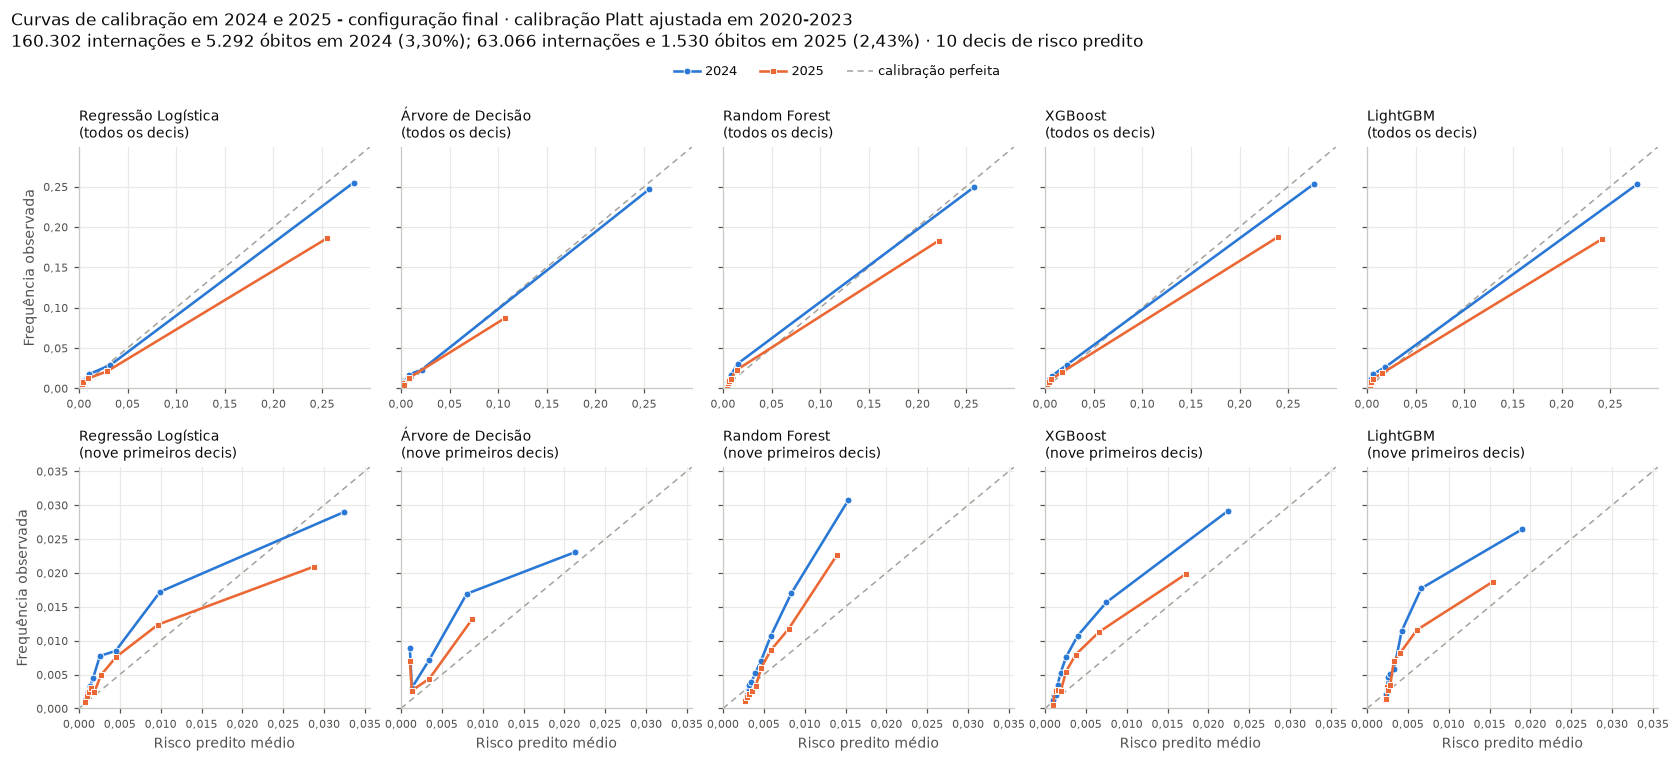

[tabela] analysis/results_equidade/desvio_calibracao_por_ano.csv  (10 linhas)


,algoritmo,ano,desvio_medio_absoluto,desvio_maximo_absoluto,risco_predito_medio,frequencia_observada,n_base,eventos
0,LightGBM,2024,0.00587,0.02483,0.03235,0.03301,160302.0,5292.0
1,LightGBM,2025,0.00767,0.05674,0.02832,0.02426,63066.0,1530.0
2,Random Forest,2024,0.00445,0.01537,0.03085,0.03301,160302.0,5292.0
3,Random Forest,2025,0.00609,0.03877,0.02707,0.02426,63066.0,1530.0
4,Regressão Logística,2024,0.00543,0.02748,0.03377,0.03301,160302.0,5292.0
5,Regressão Logística,2025,0.00894,0.06921,0.03074,0.02426,63066.0,1530.0
6,XGBoost,2024,0.00568,0.02323,0.03198,0.03301,160302.0,5292.0
7,XGBoost,2025,0.00710,0.05194,0.02765,0.02426,63066.0,1530.0
8,Árvore de Decisão,2024,0.00541,0.00886,0.03084,0.03301,160302.0,5292.0
9,Árvore de Decisão,2025,0.00652,0.01996,0.02748,0.02426,63066.0,1530.0


In [24]:
def curva_decis(y, p, n_bins=N_DECIS):
    '''Decis do risco predito: média predita e frequência observada em cada faixa.'''
    q = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    q[0], q[-1] = -np.inf, np.inf
    faixa = np.clip(np.searchsorted(q, p, side='right') - 1, 0, n_bins - 1)
    pred, obs, tam, ev = [], [], [], []
    for b in range(n_bins):
        m = faixa == b
        if not m.any():
            continue
        pred.append(float(p[m].mean())); obs.append(float(y[m].mean()))
        tam.append(int(m.sum())); ev.append(int(y[m].sum()))
    return np.array(pred), np.array(obs), np.array(tam), np.array(ev)


linhas, curvas, lim = [], {}, 0.0
for algo, rotulo in ALGORITMOS.items():
    k = chave_de(algo, CONFIG_PRINCIPAL)
    for ano, y_ano in ((ANO_TESTE, Y_2024), (ANO_EXTERNO, Y_2025)):
        pred, obs, tam, ev = curva_decis(y_ano, probabilidades[k][ano])
        curvas[(algo, ano)] = (pred, obs)
        lim = max(lim, pred.max(), obs.max())
        for d, (pr, ob, t, e) in enumerate(zip(pred, obs, tam, ev), start=1):
            linhas.append({
                'algoritmo': rotulo, 'configuracao': ROTULO_CONFIG[CONFIG_PRINCIPAL],
                'ano': ano, 'decil': d, 'n_base': t, 'eventos': e,
                'risco_predito_medio': round(pr, 5),
                'frequencia_observada': round(ob, 5),
                'diferenca': round(pr - ob, 5),
                'n_base_ano': len(y_ano), 'eventos_ano': int(y_ano.sum()),
            })
lim = min(1.0, lim * 1.06)
# O decil de maior risco domina a escala e comprime os outros nove; a segunda linha da
# figura repete o mesmo desenho recortado abaixo do décimo decil.
lim_zoom = min(1.0, max(max(pred[:-1].max(), obs[:-1].max())
                        for pred, obs in curvas.values()) * 1.10)

df_curva = pd.DataFrame(linhas)
salvar_tab(df_curva, 'curva_calibracao_por_decil.csv')

fig, axes = plt.subplots(2, len(ALGORITMOS), figsize=(15.2, 6.9), sharex='row', sharey='row')
for i, teto in enumerate((lim, lim_zoom)):
    for j, (algo, rotulo) in enumerate(ALGORITMOS.items()):
        ax = axes[i, j]
        for ano in (ANO_TESTE, ANO_EXTERNO):
            pred, obs = curvas[(algo, ano)]
            # A linha de baixo desenha só os nove primeiros decis, como diz o título:
            # incluir o décimo deixaria o traço saindo pelo topo do painel recortado.
            if i == 1:
                pred, obs = pred[:-1], obs[:-1]
            ax.plot(pred, obs, MARCAS_ANO[ano] + '-', color=CORES_ANO[ano], markersize=4.5,
                    linewidth=1.7, markeredgecolor='#ffffff', markeredgewidth=0.6,
                    label=f'{ano}')
        ax.plot([0, teto], [0, teto], color=COR_REF, linewidth=1, linestyle=(0, (4, 3)),
                zorder=1, label='calibração perfeita' if (i, j) == (0, 0) else None)
        ax.set_xlim(0, teto); ax.set_ylim(0, teto)
        ax.set_title(f'{rotulo}\n({"todos os decis" if i == 0 else "nove primeiros decis"})',
                     loc='left', fontsize=9)
        ax.grid(True, alpha=0.9, zorder=0); ax.set_axisbelow(True)
        casas = 2 if teto > 0.1 else 3
        ax.xaxis.set_major_formatter(eixo_virgula(casas))
        ax.yaxis.set_major_formatter(eixo_virgula(casas))
        ax.tick_params(labelsize=7.5)
        if i == 1:
            ax.set_xlabel('Risco predito médio')
        if j == 0:
            ax.set_ylabel('Frequência observada')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.89))
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=3,
           fontsize=8.5, handletextpad=0.4, columnspacing=1.8)
fig.suptitle(
    f'Curvas de calibração em {ANO_TESTE} e {ANO_EXTERNO} - configuração '
    f'{ROTULO_CONFIG[CONFIG_PRINCIPAL]} · calibração {CALIBRACAO} ajustada em 2020-2023\n'
    f'{n_(N_2024)} internações e {n_(EVENTOS_2024)} óbitos em {ANO_TESTE} '
    f'({pct_(PREV_2024 * 100, 2)}); {n_(N_2025)} internações e {n_(EVENTOS_2025)} óbitos em '
    f'{ANO_EXTERNO} ({pct_(PREV_2025 * 100, 2)}) · {N_DECIS} decis de risco predito',
    x=0.006, y=0.995, ha='left', va='top', fontsize=11)
salvar_fig(fig, 'calibracao_decis_2024_2025.png')
plt.show()

df_desvio = (df_curva.groupby(['algoritmo', 'ano'], observed=True)
             .apply(lambda g: pd.Series({
                 'desvio_medio_absoluto': round(float(g['diferenca'].abs().mean()), 5),
                 'desvio_maximo_absoluto': round(float(g['diferenca'].abs().max()), 5),
                 'risco_predito_medio': round(float(
                     (g['risco_predito_medio'] * g['n_base']).sum() / g['n_base'].sum()), 5),
                 'frequencia_observada': round(float(
                     (g['frequencia_observada'] * g['n_base']).sum() / g['n_base'].sum()), 5),
                 'n_base': int(g['n_base'].sum()), 'eventos': int(g['eventos'].sum()),
             }), include_groups=False).reset_index())
salvar_tab(df_desvio, 'desvio_calibracao_por_ano.csv')
display(df_desvio)

## Conclusões

- Na configuração final os cinco pares base/otimizada ficam agora com a versão otimizada, com
  diferença de AUPRC na validação cruzada do treino de 0,0001 a 0,0477.
  O empate exato do Random Forest, que na execução anterior estava na final, migrou para a
  configuração sem critérios de gravidade, 0,2755 nas duas versões, onde a base foi mantida por parcimônia.

- O critério de inclusão é a largura observada do IC 95% da estatística C: o subgrupo entra
  quando ela fica abaixo de 0,10 nos cinco modelos.
  O critério anterior era um limiar arbitrário de 30 eventos; aqui o subgrupo entra pela
  precisão que de fato alcança, no espírito de Riley et al. (2021).
  Não há conversão para número de eventos, ajuste de curva nem extrapolação, e a exigência nos
  cinco modelos mantém o conjunto de subgrupos idêntico entre as tabelas dos cinco algoritmos.

- Dezesseis dos dezenove níveis atendem ao critério.
  Ficam de fora raça/cor amarela, de 0,0693 a 0,1111 sobre 52 óbitos; raça/cor indígena, de
  0,0662 a 0,1737 sobre 14 óbitos; e Norte, de 0,0802 a 0,1015 sobre 37 óbitos.
  Os 22 subgrupos reportados são esses 19 níveis, mais 2 categorias de não resposta e 1 de não
  resposta estrutural.

- Em 95 dos 100 pares subgrupo-modelo a largura fica abaixo do alvo.
  As cinco falhas se espalham mais que antes: duas na Decision Tree e uma em cada uma da
  Logistic Regression, do Random Forest e do LightGBM; no XGBoost nenhum subgrupo passa do alvo.

- A largura não acompanha o número de óbitos de forma ordenada, o que é a razão de o critério ser
  medido na própria largura.
  O subgrupo indígena, com 14 óbitos, tem largura de 0,0662 no XGBoost, menor que a do subgrupo
  amarelo, com 52 óbitos e largura mínima de 0,0693; e menores de 15 anos, com 160 óbitos, chega
  a 0,0688, enquanto escolaridade não se aplica, com 95 óbitos, chega a 0,0913.

- O limiar antigo de 30 óbitos admitiria 19 das 20 categorias, com largura observada de até
  0,1111 na estatística C e 0,3297 na AUPRC.
  O limiar de 100 óbitos admitiria 16, com largura observada de até 0,0688 e 0,1805.

- A largura do IC da AUPRC supera a da estatística C no mesmo subgrupo por um fator de 2,55 a
  3,19, conforme a faixa de tamanho.
  A AUPRC não entra no critério.

- A não resposta de raça/cor e de escolaridade passou a ser reportada como subgrupo, com n,
  óbitos, ponto e intervalo, porque na codificação final essas duas declaram o ausente ao
  codificador e ocupam coluna na matriz de desenho.
  Raça/cor não informada reúne 19.733 internações e 516 óbitos, com AUPRC de 0,5780 a 0,6443;
  escolaridade não informada reúne 80.838 e 2.828, com AUPRC de 0,5667 a 0,6340.
  Nenhuma das duas é a pior da sua variável, e as duas ficam fora do cálculo de disparidade, que
  compara categorias entre si.

- A categoria "não se aplica" da escolaridade recebe agora o mesmo tratamento,
  por motivo próprio: ela não é um nível de escolaridade, e sim a categoria de não aplicação do
  campo, concentrada nas primeiras idades da coorte.
  Reúne 12.861 internações e 95 óbitos, e a largura do seu IC, de 0,0913, atende ao alvo: não é
  por falta de precisão que ela sai do cálculo.
  As tabelas e as figuras passam a separar três motivos de ficar fora: largura insuficiente do
  intervalo, não resposta e não resposta estrutural.

- Menores de 15 anos é o subgrupo de menor AUPRC da faixa etária nos cinco modelos, entre 0,4179
  e 0,5069, contra 0,5998 a 0,6639 em 60 anos ou mais.
  A disparidade por faixa etária tem mediana de 0,1572 e vai de 0,1555 a 0,2300.

- Com o limiar igual para todos os subgrupos, a sensibilidade em menores de 15 anos fica entre
  0,7125 e 0,7312 e em 60 anos ou mais entre 0,8103 e 0,9127; a disparidade de sensibilidade da
  faixa etária tem mediana de 0,1134.

- O VPP em menores de 15 anos fica entre 0,1706 e 0,2035, num subgrupo de prevalência 0,6%.

- O Nordeste é o subgrupo de menor AUPRC da macrorregião nos cinco modelos, entre 0,5095 e
  0,5760, contra 0,6124 a 0,6793 no melhor de cada modelo, que é o Sul em quatro deles e o
  Centro-Oeste na Logistic Regression.
  A disparidade por macrorregião tem mediana de 0,1029 e a de sensibilidade, 0,0937, com a
  sensibilidade no Nordeste entre 0,6926 e 0,7316.

- Os dois subgrupos apontados como piores no padrão publicado atendem ao critério de largura e
  continuam sendo os de menor AUPRC depois da calibração e da troca de limiar: menores de 15 anos
  nos cinco modelos e Nordeste nos cinco modelos.

- A escolaridade entra no cálculo com quatro níveis.
  Com "não se aplica" dentro, a disparidade ia de 0,2525 a 0,3041 e era a maior das cinco
  variáveis, mas o que ela media era a disparidade por faixa etária, já reportada na própria
  faixa etária, reexpressa numa segunda variável.
  Fora dele, vai de 0,0690 a 0,0790, com mediana 0,0758, e a escolaridade cai de primeira para
  terceira entre as cinco, abaixo da macrorregião, cuja faixa de 0,0970 a 0,1097 não chega a
  tocar a dela.
  O menor AUPRC passa a ser o do nível médio nos cinco modelos, de 0,5668 a 0,6309, contra
  fundamental II, de 0,6458 a 0,7071.

- A disparidade de sensibilidade da escolaridade cai junto, de mediana 0,1065 para 0,0709, porque
  "não se aplica" era também o subgrupo de menor sensibilidade nos cinco modelos.
  A queda vai de 0,0321 no LightGBM a 0,1294 na Decision Tree.
  O novo mínimo é o nível superior em quatro modelos e o médio no Random Forest.

- Sexo é a variável de menor disparidade: mediana de 0,0037 na AUPRC, entre 0,0015 e 0,0079, e de
  0,0015 na sensibilidade.

- Em raça/cor a menor AUPRC está sempre no grupo pardo, com disparidade mediana de 0,0546, entre
  0,0431 e 0,0598.

- Nenhuma métrica ficou indefinida: as 2.000 réplicas do bootstrap são válidas nos 110 pares
  subgrupo-modelo, inclusive no subgrupo indígena.

- A prevalência do desfecho cai de 3,3% em 2024 para 2,4% em 2025, sobre 160.302 e 63.066
  internações.

- A AUPRC cai em 2025 nos cinco modelos, de 0,0416 a 0,0528, com intervalos de confiança que não
  incluem zero.

- O ROC-AUC varia entre -0,0073 e -0,0027, com intervalos que incluem zero nos cinco modelos.

- A sensibilidade vai de -0,0201 a +0,0074, com intervalo que inclui zero nos cinco modelos,
  enquanto o VPP cai de 0,0363 a 0,0449, com intervalos que não incluem zero em nenhum.

- O Brier Score melhora de 0,00317 a 0,00411 em 2025 e o Brier Skill Score piora de 0,0539 a
  0,0674, os dois com intervalos que não incluem zero nos cinco modelos.

- O risco predito médio supera a frequência observada em 2025 nos cinco modelos, por exemplo
  0,03074 contra 0,02426 na Logistic Regression, enquanto em 2024 ficava abaixo da observada em
  quatro dos cinco.

- O desvio médio absoluto por decil entre risco predito e frequência observada sobe em 2025 nos
  cinco modelos, de 0,00543 para 0,00894 na Logistic Regression e de 0,00541 para 0,00652 na
  Decision Tree, e o desvio máximo sobe de 0,02748 para 0,06921 e de 0,00886 para 0,01996
  nesses mesmos dois.

- Na configuração sem critérios de gravidade a disparidade de AUPRC por faixa etária tem mediana de 0,2223 e
  a de sensibilidade, 0,3398, com a sensibilidade em menores de 15 anos entre 0,4875 e 0,6188
  contra 0,8826 a 0,9030 em 60 anos ou mais.
  A AUPRC mediana entre os subgrupos elegíveis é 0,2607, contra 0,6232 na configuração final.
